In [ ]:
# !pip install gymnasium matplotlib numpy 

In [1]:
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from matplotlib.colors import ListedColormap
import pickle

from matplotlib.offsetbox import AnnotationBbox, OffsetImage


In [2]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')
!pwd

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
/content


In [3]:
folder_path = "/content/drive/MyDrive/MS/RL/Assignment1/"

In [4]:
############# Environment (Random Package location) ##############

class GridEnvironmentS2(gym.Env):
    # Attribute of Gym class that provides info about the render modes
    metadata = { 'render.modes': [] }

    # Initialization function
    def __init__(self, env_type, max_timestep):

      self.env_type = env_type
      self.observation_space = spaces.Discrete(2*36*36)
      self.action_space = spaces.Discrete(6)
      self.max_timesteps = max_timestep

      self.timestep = 0
      self.agent_pos = [0, 5]
      self.package = False
      self.warehouse_pos = [0, 0]
      self.goal_pos = [5, 5]
      self.obstacle_pos = [3, 3]

      self.colors_list = ['white','black', 'red', 'green', 'yellow',  'blue']
      self.custom_color_map = ListedColormap(self.colors_list)

      self.state = np.zeros((6,6))
      self.state[tuple(self.warehouse_pos)] = 1 #warehouse - black
      self.state[tuple(self.obstacle_pos)] = 2 #obstacle - red
      self.state[tuple(self.goal_pos)] = 3 #goal - green
      if self.package == False:
        self.state[tuple(self.agent_pos)] = 5 #agent(without package) - blue
      else:
        self.state[tuple(self.agent_pos)] = 4 #agent(with package) - yellow

      self.images = {
            'agent_empty': plt.imread(folder_path + "images/without_package.png"),   # State 1: No package
            'agent_loaded': plt.imread(folder_path + "images/with_package.png"), # State 2: Has package
            'warehouse': plt.imread(folder_path + "images/package.png"),            # Warehouse
            'goal': plt.imread(folder_path + "images/delivery.png"),        # Goal
            'obstacle': plt.imread(folder_path + "images/obstacle.png")       # Obstacle
        }


    # Reset function
    def obs1_to_obs2(self,obs1):
      agent_pos, has_pack, warehouse_pos = obs1
      if has_pack:
        obs2 = [agent_pos[0],agent_pos[1],1,warehouse_pos[0],warehouse_pos[1]]
      else:
        obs2 = [agent_pos[0],agent_pos[1],0,warehouse_pos[0],warehouse_pos[1]]
      return obs2

    def reset_random_spawn(self, **kwargs):

      self.timestep = 0
      self.agent_pos = [0, 5]
      self.package = False
      self.pick_count = 0

      grid = 6
      warehouse_posn_not_allowed = [tuple(self.agent_pos), tuple(self.goal_pos), tuple(self.obstacle_pos)]
      while True:
        warehouse_pos = (random.randint(0,(grid-1)), random.randint(0,(grid-1)))
        if warehouse_pos not in warehouse_posn_not_allowed:
          self.warehouse_pos = list(warehouse_pos)
          break

      self.state = np.zeros((6,6))
      self.state[tuple(self.warehouse_pos)] = 1
      self.state[tuple(self.obstacle_pos)] = 2
      self.state[tuple(self.goal_pos)] = 3
      if self.package == False:
        self.state[tuple(self.agent_pos)] = 5
      else:
        self.state[tuple(self.agent_pos)] = 4
      # observation = self.state.flatten()
      observation = (self.agent_pos, self.package, self.warehouse_pos)
      observation = self.obs1_to_obs2(observation)

      info = {'warehouse_pos': self.warehouse_pos}

      return observation, info

    # Step function: implementation for what happens when an
    # agent takes a step in the environment.
    def step(self, action):

      # Information about agent before taking the action: position and if the agent had package or not
      agent_position = self.agent_pos.copy()
      warehouse_pos = self.warehouse_pos.copy()
      package_condition = self.package
      info = {'agent_pos' : agent_position,
              'has_package' : package_condition,
              'warehouse_pos': warehouse_pos}
      reward = 0

      terminated = False
      truncated = False

      # Defining 6 actions
      # Deterministic actions conditions
      if self.env_type == 'dt': # Deterministic
        if action == 0: #down
          if self.package:
            self.warehouse_pos[0] += 1
          self.agent_pos[0] += 1
          reward = -1
        if action == 1: #up
          if self.package:
            self.warehouse_pos[0] -= 1
          self.agent_pos[0] -= 1
          reward = -1
        if action == 2: #right
          if self.package:
            self.warehouse_pos[1] += 1
          self.agent_pos[1] += 1
          reward = -1
        if action == 3: #left
          if self.package:
            self.warehouse_pos[1] -= 1
          self.agent_pos[1] -= 1
          reward = -1
        if action == 4: #Pick
          if not(self.package):
            if np.array_equal(self.agent_pos,self.warehouse_pos) and self.pick_count==0:
              self.package = True
              reward = 25
              self.pick_count += 1
            elif np.array_equal(self.agent_pos,self.warehouse_pos) and self.pick_count>0:
              self.package = True
              reward = -1
            else:
              reward = -5
          else:
            reward = -5
        if action == 5: #Drop
          if (self.package):
            if np.array_equal(self.agent_pos,self.goal_pos):
              self.package = False
              reward = 100
              terminated = True
            else:
              self.package = False
              reward = -5
          else:
            reward = -5

      # Stochastic conditions
      elif self.env_type == 'st': #stochastic
        p = random.random()
        if action == 0: #down
          if p < 0.9:
            if self.package:
              self.warehouse_pos[0] += 1
            self.agent_pos[0] += 1
          elif p < 0.93:
            if self.package:
              self.warehouse_pos[0] -= 1
            self.agent_pos[0] -= 1
          elif p < 0.96:
            if self.package:
              self.warehouse_pos[1] += 1
            self.agent_pos[1] += 1
          else:
            if self.package:
              self.warehouse_pos[1] -= 1
            self.agent_pos[1] -= 1
          if self.package and self.agent_pos[0]<5:
            reward = +1
          else:
            reward = -1

        if action == 1: #up
          if p < 0.9:
            if self.package:
              self.warehouse_pos[0] -= 1
            self.agent_pos[0] -= 1
          elif p < 0.93:
            if self.package:
              self.warehouse_pos[0] += 1
            self.agent_pos[0] += 1
          elif p < 0.96:
            if self.package:
              self.warehouse_pos[1] += 1
            self.agent_pos[1] += 1
          else:
            if self.package:
              self.warehouse_pos[1] -= 1
            self.agent_pos[1] -= 1
          reward = -1

        if action == 2: #right
          if p < 0.9:
            if self.package:
              self.warehouse_pos[1] += 1
            self.agent_pos[1] += 1
          elif p < 0.93:
            if self.package:
              self.warehouse_pos[0] -= 1
            self.agent_pos[0] -= 1
          elif p < 0.96:
            if self.package:
              self.warehouse_pos[0] += 1
            self.agent_pos[0] += 1
          else:
            if self.package:
              self.warehouse_pos[1] -= 1
            self.agent_pos[1] -= 1
          if self.package and self.agent_pos[1]<5:
            reward = +1
          else:
            reward = -1

        if action == 3: #left
          if p < 0.9:
            if self.package:
              self.warehouse_pos[1] -= 1
            self.agent_pos[1] -= 1
          elif p < 0.93:
            if self.package:
              self.warehouse_pos[0] -= 1
            self.agent_pos[0] -= 1
          elif p < 0.96:
            if self.package:
              self.warehouse_pos[0] += 1
            self.agent_pos[0] += 1
          else:
            if self.package:
              self.warehouse_pos[1] += 1
            self.agent_pos[1] += 1
          reward = -1

        if action == 4: #Pick
          if not(self.package):
            if np.array_equal(self.agent_pos,self.warehouse_pos) and self.pick_count==0:
              self.package = True
              reward = 25
              self.pick_count += 1
            elif np.array_equal(self.agent_pos,self.warehouse_pos) and self.pick_count>0:
              self.package = True
              reward = -1
            else:
              reward = -5
          else:
            reward = -5
        if action == 5: #Drop
          if (self.package):
            if np.array_equal(self.agent_pos,self.goal_pos):
              self.package = False
              reward = 100
              terminated = True
            else:
              self.package = False
              reward = -5
          else:
            reward = -5

      # Limiting the agent on the assigned grid
      self.agent_pos = np.clip(self.agent_pos, 0, 5)
      self.warehouse_pos = np.clip(self.warehouse_pos, 0, 5)

      self.state = np.zeros((6,6))
      self.state[tuple(self.warehouse_pos)] = 1
      self.state[tuple(self.obstacle_pos)] = 2
      self.state[tuple(self.goal_pos)] = 3
      if self.package == False:
        self.state[tuple(self.agent_pos)] = 5
      else:
        self.state[tuple(self.agent_pos)] = 4
      # observation = self.state.flatten()
      observation = (self.agent_pos, self.package, self.warehouse_pos)
      observation = self.obs1_to_obs2(observation)


      if np.array_equal(self.agent_pos, self.obstacle_pos):
        reward += -100

      self.timestep += 1

      if not terminated:
        # termination condition (episode is over)
        terminated = True if self.timestep >= self.max_timesteps else False

      # Condition to check if agent is traversing to a cell beyond the permitted cells
      # This helps the agent to learn how to behave in a safe and predictable manner
      truncated = False if np.all((np.asarray(self.agent_pos) >=0 ) & (np.asarray(self.agent_pos) <= 5)) else True

      return observation, reward, terminated, truncated, info

    def get_agent_status(self):
        return self.images['agent_loaded'] if self.package else self.images['agent_empty']

    # Render function: Visualization
    def render(self, mode='human'):
        fig, ax = plt.subplots(figsize=(6, 6))

        def add_sprite(img, pos):
            oi = OffsetImage(img, zoom=0.1)
            ab = AnnotationBbox(oi, (pos[1], pos[0]), frameon=False)
            ax.add_artist(ab)

        add_sprite(self.images['warehouse'], self.warehouse_pos)
        add_sprite(self.images['goal'], self.goal_pos)
        add_sprite(self.images['obstacle'], self.obstacle_pos)
        add_sprite(self.get_agent_status(), self.agent_pos)

        ax.set_xticks(np.arange(-0.5, 6, 1))
        ax.set_yticks(np.arange(-0.5, 6, 1))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(color='black', linestyle='-', linewidth=1, alpha=0.5)
        plt.title(f"Step: {self.timestep} | Package: {self.package}")

        plt.show()

    def obs_to_state_s2(self, obs):
      if not obs[1]:
        state = 432*obs[2][0] + 72*obs[2][1] + 12*obs[0][0]+ 2*obs[0][1]
      else:
        state = 432*obs[2][0]+ 72*obs[2][1] + 12*obs[0][0]+ 2*obs[0][1] + 1
      return state


In [5]:
###### DQN Algorithm parts ########
import random
from collections import deque
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class DQN:
  def __init__(self, env, epsilon,epsilon_decay_mag,alpha,gamma,q_net,target_net,buffer_size,training_start_size,minibatch_size, learning_rate):
    self.env = env
    self.observation_space = env.observation_space
    self.action_space = env.action_space
    self.epsilon = epsilon
    self.epsilon_decay_mag = epsilon_decay_mag
    self.alpha = alpha
    self.gamma = gamma
    self.q_net = q_net
    self.target_net = target_net
    self.buff_size = buffer_size
    self.buffer = deque()
    self.training_start_size = training_start_size
    self.minibatch_size = minibatch_size
    self.learning_rate = learning_rate
    self.optimizer = optim.Adam(self.q_net.parameters(), lr=self.learning_rate)

  def obs_to_tensor(self, obs):
    state = torch.tensor(obs, dtype=torch.float32)
    return state

  def step(self, state1):
    self.state1 = self.obs_to_tensor(state1)
    if np.random.random()<self.epsilon:
      action = np.random.choice(self.action_space.n)
    else:
      action = torch.argmax(self.q_net(self.state1))
      action = action.item()
    return action

  def buffer_save(self, exp):
    if len(self.buffer) < self.buff_size:
      self.buffer.append(exp)
    elif len(self.buffer) >= self.buff_size:
      self.buffer.popleft()
      self.buffer.append(exp)

  def grad_update(self):

    ## Batch processing in pytorch network
    mini_batch = random.sample(self.buffer, self.minibatch_size)
    states1, actions, rewards, states2, done = zip(*mini_batch)
    tensor_states1 = torch.tensor(states1, dtype=torch.float32)
    tensor_actions = torch.tensor(actions).unsqueeze(1)
    tensor_rewards = torch.tensor(rewards, dtype=torch.float32)
    tensor_states2 = torch.tensor(states2, dtype=torch.float32)

    tensor_done = torch.from_numpy(np.array(done, dtype=np.float32))

    # print("state shape", tensor_states1.shape)
    # print("actions shape", tensor_actions.shape)
    # print(tensor_actions)
    # print("rewards shape", tensor_rewards.shape)
    # print(tensor_done.shape)

    q_pred = self.q_net(tensor_states1)
    q_pred = q_pred.gather(1,tensor_actions).squeeze(1)
    # print(q_pred)

    with torch.no_grad():
      q_target = self.target_net(tensor_states2)
      q_target, tensor_actions2 = torch.max(q_target,dim=1)
      tensor_ones = torch.ones_like(tensor_done)
      q_target = tensor_rewards + (self.gamma * q_target * (tensor_ones-tensor_done))
      # print(q_target)

    loss = (q_target-q_pred)*(q_target-q_pred)
    loss = torch.sum(loss)*(1/self.minibatch_size)

    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()

    return loss

  def grad_update_double_dqn(self):

    ## Batch processing in pytorch network
    mini_batch = random.sample(self.buffer, self.minibatch_size)
    states1, actions, rewards, states2, done = zip(*mini_batch)
    tensor_states1 = torch.tensor(states1, dtype=torch.float32)
    tensor_actions = torch.tensor(actions).unsqueeze(1)
    tensor_rewards = torch.tensor(rewards, dtype=torch.float32)
    tensor_states2 = torch.tensor(states2, dtype=torch.float32)

    tensor_done = torch.from_numpy(np.array(done, dtype=np.float32))

    q_pred = self.q_net(tensor_states1)
    q_pred = q_pred.gather(1,tensor_actions).squeeze(1)
    # print(q_pred)

    with torch.no_grad():
      online_q_next = self.q_net(tensor_states2)
      _, best_actions_next = torch.max(online_q_next, dim=1)
      best_actions_next = best_actions_next.unsqueeze(1)

      target_q_values = self.target_net(tensor_states2)
      q_target_next = target_q_values.gather(1, best_actions_next).squeeze(1)
      tensor_ones = torch.ones_like(tensor_done)
      q_target = tensor_rewards + (self.gamma * q_target_next * (tensor_ones-tensor_done))
      # print(q_target)

    loss = (q_target-q_pred)*(q_target-q_pred)
    loss = torch.sum(loss)*(1/self.minibatch_size)

    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()

    return loss

  def target_net_sync(self):
    self.target_net.load_state_dict(self.q_net.state_dict())
    # print(self.q_net.state_dict())

  def epsilon_decay(self):
    self.epsilon = (self.epsilon)*(self.epsilon_decay_mag)

## optimal-policy agent rollout
class DQN_Agent_Roll:

  def __init__(self, env, q_net_optimal):
    self.q_net_optimal = q_net_optimal
    self.env = env

  def obs_to_tensor(self, obs):
    state = torch.tensor(obs, dtype=torch.float32)
    return state

  def greedy_step(self, state1):
    self.state1 = self.obs_to_tensor(state1)
    action = torch.argmax(self.q_net_optimal(self.state1))
    action = action.item()
    return action



In [ ]:
# --------------------------------------
# Gridworld (DQN)
# --------------------------------------

In [48]:
### Neural net architecture for Gridwrold DQN ###
class net(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(5, 64)
    self.fc2 = nn.Linear(64, 64)
    self.fc3 = nn.Linear(64,6)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x

print(net())

net(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=6, bias=True)
)


Streaming output truncated to the last 5000 lines.
5000
5001
5002
5003
5004
5005
5006
5007
5008
5009
5010
5011
5012
5013
5014
5015
5016
5017
5018
5019
5020
5021
5022
5023
5024
5025
5026
5027
5028
5029
5030
5031
5032
5033
5034
5035
5036
5037
5038
5039
5040
5041
5042
5043
5044
5045
5046
5047
5048
5049
5050
5051
5052
5053
5054
5055
5056
5057
5058
5059
5060
5061
5062
5063
5064
5065
5066
5067
5068
5069
5070
5071
5072
5073
5074
5075
5076
5077
5078
5079
5080
5081
5082
5083
5084
5085
5086
5087
5088
5089
5090
5091
5092
5093
5094
5095
5096
5097
5098
5099
5100
5101
5102
5103
5104
5105
5106
5107
5108
5109
5110
5111
5112
5113
5114
5115
5116
5117
5118
5119
5120
5121
5122
5123
5124
5125
5126
5127
5128
5129
5130
5131
5132
5133
5134
5135
5136
5137
5138
5139
5140
5141
5142
5143
5144
5145
5146
5147
5148
5149
5150
5151
5152
5153
5154
5155
5156
5157
5158
5159
5160
5161
5162
5163
5164
5165
5166
5167
5168
5169
5170
5171
5172
5173
5174
5175
5176
5177
5178
5179
5180
5181
5182
5183
5184
5185
5186
5187
5188
5189

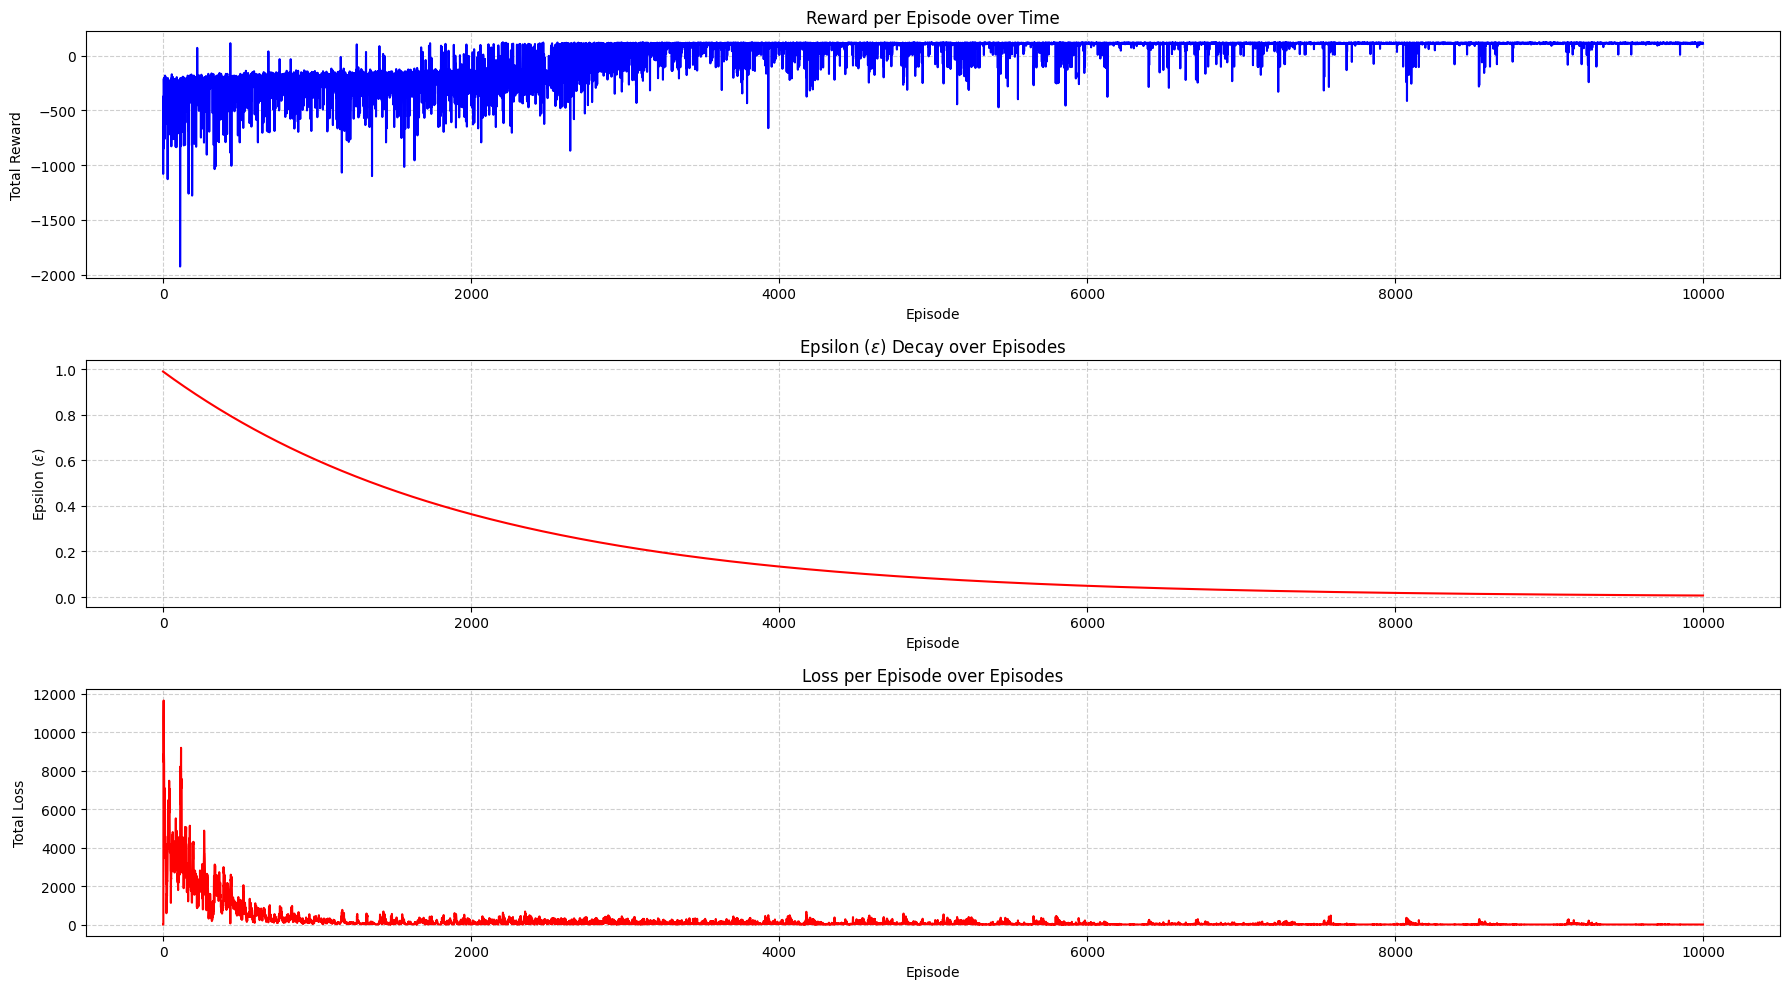

In [49]:
### Gridworld Deterministic Env DQN-training ###

if __name__ == '__main__':

  alpha = 0.2
  epsilon = 0.99
  epsilon_decay_mag = 0.9995
  gamma = 0.7
  q_net = net()
  target_net = net()
  print(q_net)
  print(target_net)
  number_episodes = 10000
  max_timesteps = 100
  buffer_size = 1000
  training_start_size = 300
  minibatch_size = 64
  learning_rate = 0.001
  grad_update_freq = 4
  target_sync_freq = 200


  env = GridEnvironmentS2('dt', max_timesteps)
  DQN_agent = DQN(env,epsilon,epsilon_decay_mag,alpha,gamma,q_net,target_net,buffer_size,training_start_size, minibatch_size, learning_rate)

  total_reward_list = []
  epsilon_list = []
  total_loss_list = []
  episodes = list(range(number_episodes))

  # list_reward_lt_20 = [] ## testing
  # no_reward_lt_20 = 0

  training_start_pointer = 0
  grad_update_pointer = 0
  target_sync_pointer = 0

  for epi in range(number_episodes):
    obs, info = env.reset_random_spawn()
    terminated, truncated = False, False
    total_reward = 0
    total_loss = torch.tensor(0.0) # Initializing as a PyTorch tensor
    step = 0
    print(epi)
    # print(env.warehouse_pos)
    # print(DQN_agent.epsilon)
    done = terminated or truncated

    while not done:

      if training_start_pointer < training_start_size:
        state1 = obs
        action = DQN_agent.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
        state2 = obs
        DQN_agent.buffer_save((state1,action,reward,state2,float(done)))
        training_start_pointer += 1

      elif training_start_pointer >= training_start_size:
        if grad_update_pointer%grad_update_freq == 0:
          loss = DQN_agent.grad_update()
          total_loss += loss
        grad_update_pointer += 1

        if target_sync_pointer%target_sync_freq==0:
          DQN_agent.target_net_sync()
        target_sync_pointer += 1

        state1 = obs
        action = DQN_agent.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
        state2 = obs
        DQN_agent.buffer_save((state1,action,reward,state2,float(done)))

      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    epsilon_list.append(DQN_agent.epsilon)
    total_reward_list.append(total_reward)
    total_loss_list.append(total_loss.item())
    DQN_agent.epsilon_decay()
    # print(total_reward)


  plt.figure(figsize=(18,10))

  # Plot 1: Episode vs Reward per Episode
  plt.subplot(3, 1, 1)
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 2: Episode vs Epsilon per Episode
  plt.subplot(3, 1, 2)
  plt.plot(episodes, epsilon_list, color='red', label=r'$\epsilon$ (Epsilon)')
  plt.title(r'Epsilon ($\epsilon$) Decay over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Epsilon ($\epsilon$)')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 3: Episode vs loss per Episode
  plt.subplot(3, 1, 3)
  plt.plot(episodes, total_loss_list, color='red', label=r'Loss')
  plt.title(r'Loss per Episode over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Total Loss')
  plt.grid(True, linestyle='--', alpha=0.6)

  plt.tight_layout()


In [50]:
grid_dqn_total_reward_list = total_reward_list

0
1
2
3
4
5
6
7
8
9
Avg reward : 115.0


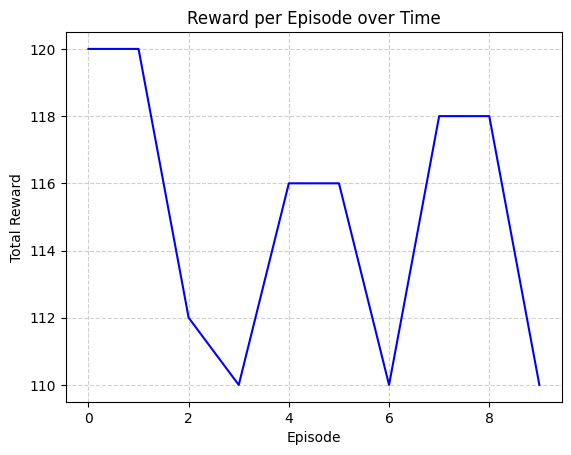

In [ ]:
### Greedy action rollout (10 episodes) ###

if __name__ == '__main__':

  q_net_grid = DQN_agent.q_net
  number_episodes = 10
  max_timestep = 100

  env2 = GridEnvironmentS2('dt', max_timesteps)
  agent2 = DQN_Agent_Roll(env2, q_net_grid)

  total_reward_list = []
  episodes = list(range(number_episodes))

  for epi in range(number_episodes):
    obs, info = env2.reset_random_spawn()
    terminated, truncated = False, False
    total_reward = 0
    step = 0
    print(epi)

    while not (terminated or truncated):

      state1 = obs
      action = agent2.greedy_step(state1)
      obs, reward, terminated, truncated, info = env2.step(action)
      total_reward += reward
      state2 = obs
      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    total_reward_list.append(total_reward)


  print(f"Avg reward : {np.sum(total_reward_list)/number_episodes}")

  # Plot: Episode vs Reward per Episode
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)




In [ ]:
# saving trained q_net as .h5 file
!pwd
folder_path = '/content/drive/MyDrive/MS/RL/Assignment2/Models/'

filename = folder_path + 'DQN_grid_dt.h5'
torch.save(DQN_agent.q_net.state_dict(), filename)
print(f"Success! q_net saved to {filename}")

/content
Success! q_net saved to /content/drive/MyDrive/MS/RL/Assignment2/Models/DQN_grid_dt.h5


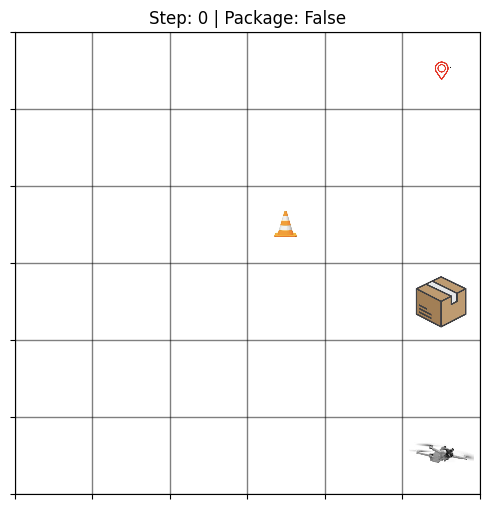

Step: 1 , Agent: [0, 5] , Has Package: False , w_house: [2, 5] , Action: 0 , Reward: -1 , Done: False


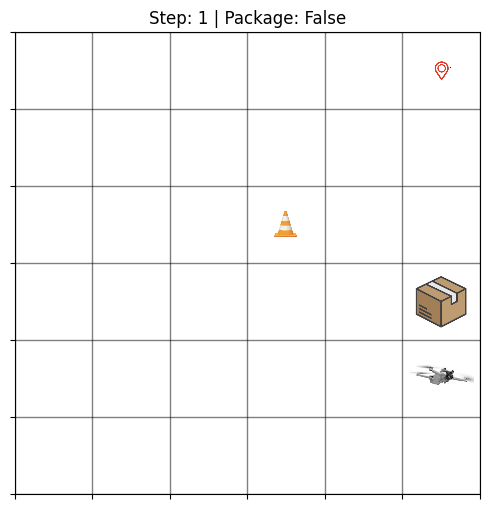

Step: 2 , Agent: [1 5] , Has Package: False , w_house: [2 5] , Action: 0 , Reward: -1 , Done: False


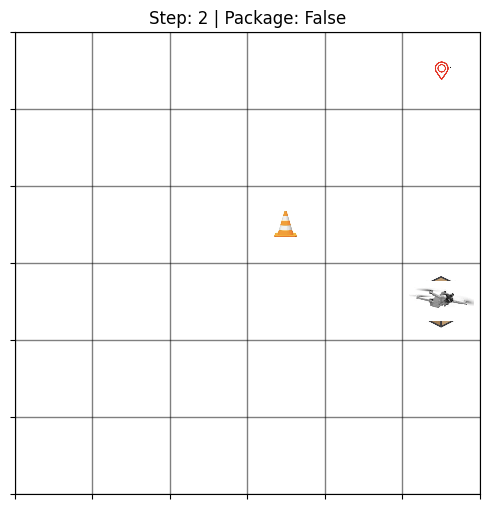

Step: 3 , Agent: [2 5] , Has Package: False , w_house: [2 5] , Action: 4 , Reward: 25 , Done: False


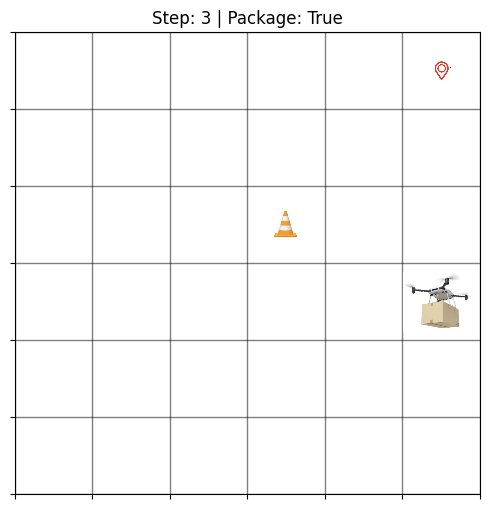

Step: 4 , Agent: [2 5] , Has Package: True , w_house: [2 5] , Action: 0 , Reward: -1 , Done: False


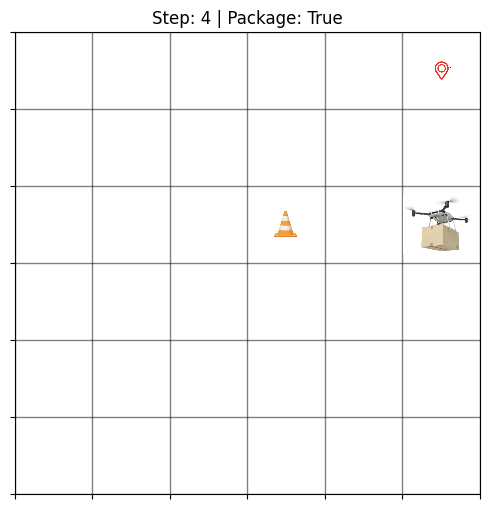

Step: 5 , Agent: [3 5] , Has Package: True , w_house: [3 5] , Action: 0 , Reward: -1 , Done: False


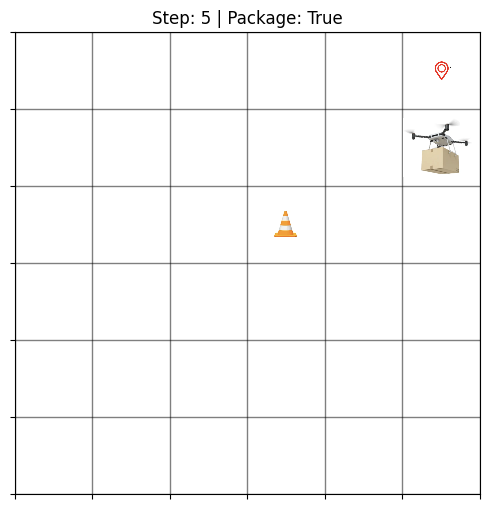

Step: 6 , Agent: [4 5] , Has Package: True , w_house: [4 5] , Action: 0 , Reward: -1 , Done: False


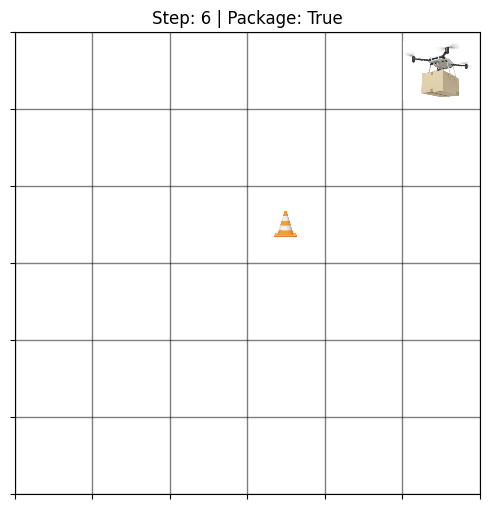

Step: 7 , Agent: [5 5] , Has Package: True , w_house: [5 5] , Action: 5 , Reward: 100 , Done: True


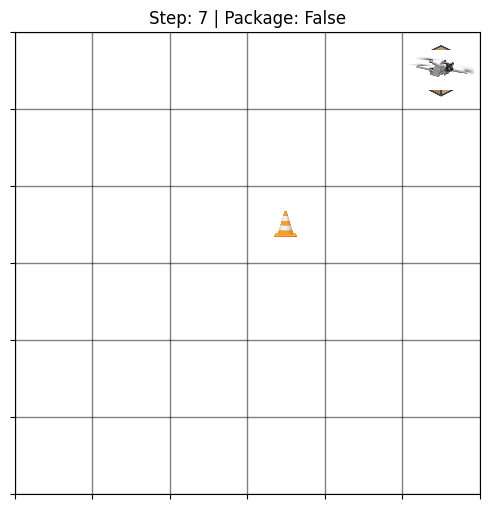

120


In [ ]:
## Rendering 1 episode

if __name__ == '__main__':

  q_net_grid = DQN_agent.q_net
  number_episodes = 1
  max_timesteps = 100

  env2 = GridEnvironmentS2('dt', max_timesteps)
  agent2 = DQN_Agent_Roll(env2, q_net_grid)

  for epi in range(number_episodes):
    obs, info = env2.reset_random_spawn()
    terminated, truncated = False, False
    total_reward = 0
    step = 0
    env2.render()

    while not (terminated or truncated):

      state1 = obs
      action = agent2.greedy_step(state1)

      obs, reward, terminated, truncated, info = env2.step(action)

      total_reward += reward
      state2 = obs
      step += 1
      print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      env2.render()
      plt.pause(0.3)

    print(total_reward)




In [ ]:
# --------------------------------------
# CartpoleV1 (DQN)
# --------------------------------------

In [68]:
import gymnasium as gym
from IPython import display
import matplotlib.pyplot as plt

In [67]:
class net_cartpole(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(4, 24)
    self.fc2 = nn.Linear(24, 24)
    self.fc3 = nn.Linear(24, 2)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x

print(net_cartpole())

net_cartpole(
  (fc1): Linear(in_features=4, out_features=24, bias=True)
  (fc2): Linear(in_features=24, out_features=24, bias=True)
  (fc3): Linear(in_features=24, out_features=2, bias=True)
)


net_cartpole(
  (fc1): Linear(in_features=4, out_features=24, bias=True)
  (fc2): Linear(in_features=24, out_features=24, bias=True)
  (fc3): Linear(in_features=24, out_features=2, bias=True)
)
net_cartpole(
  (fc1): Linear(in_features=4, out_features=24, bias=True)
  (fc2): Linear(in_features=24, out_features=24, bias=True)
  (fc3): Linear(in_features=24, out_features=2, bias=True)
)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
18

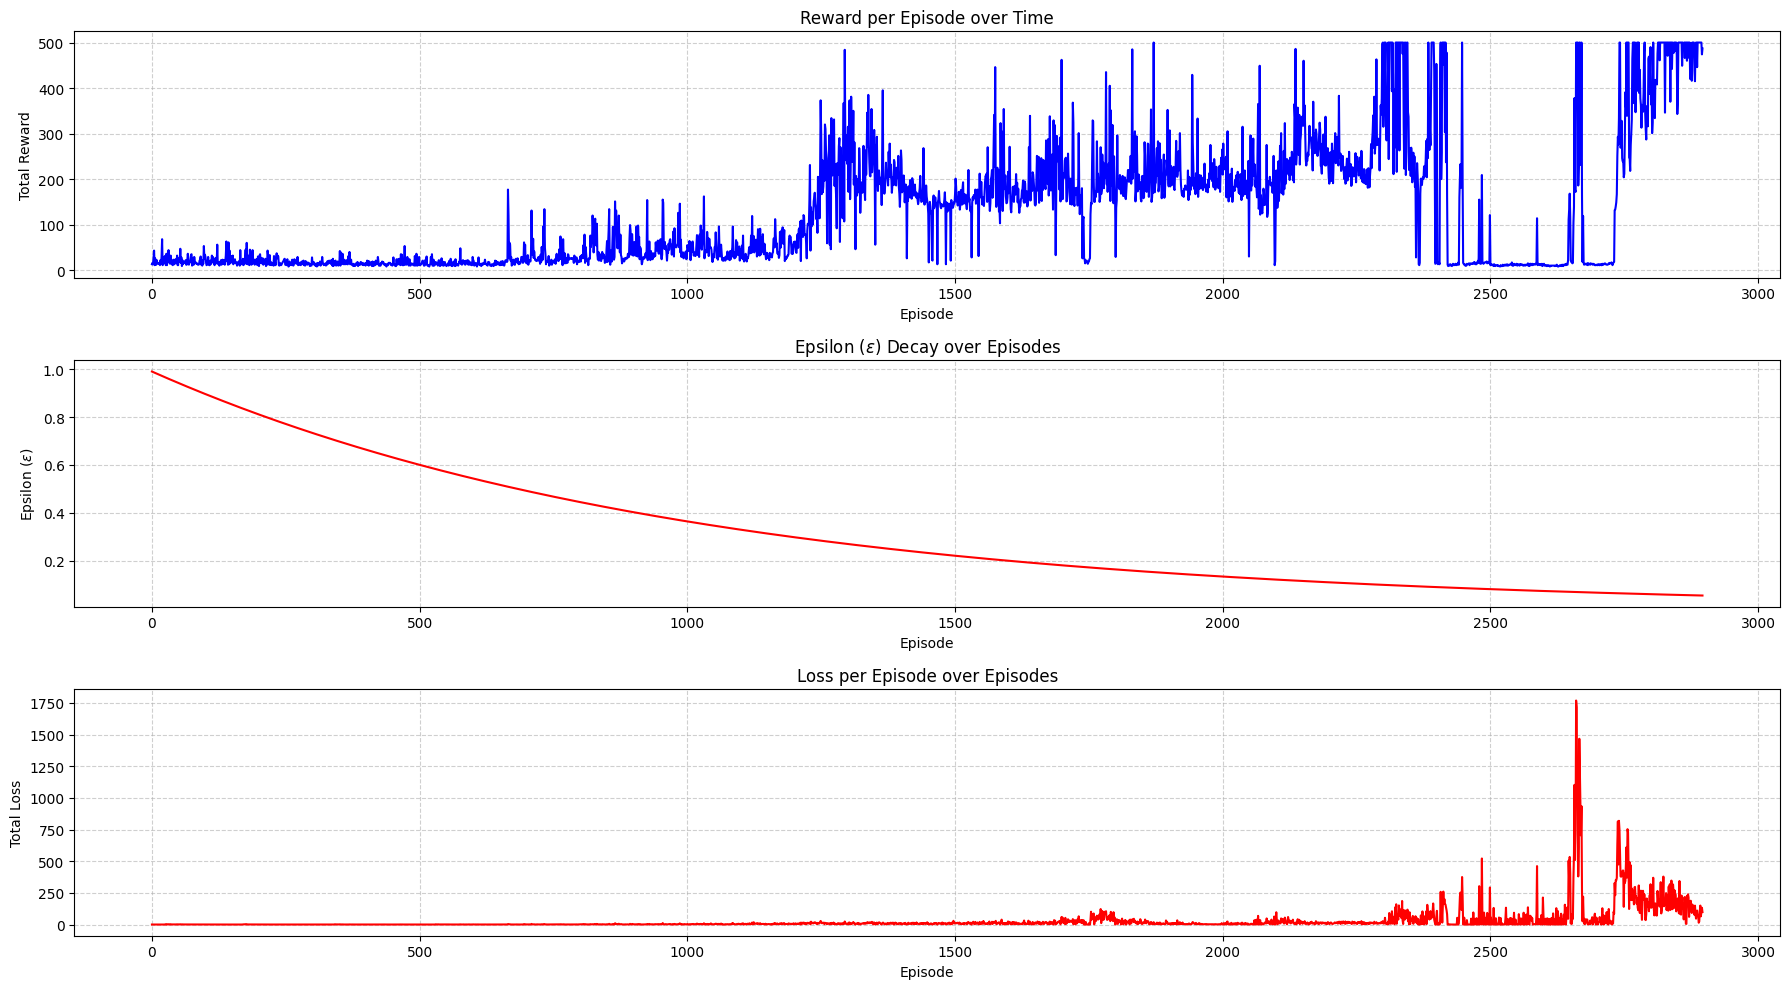

In [69]:
### Cartpole DQN-learning ###

if __name__ == '__main__':

  alpha = 0.2
  epsilon = 0.99
  epsilon_decay_mag = 0.999
  gamma = 0.99
  q_net = net_cartpole()
  target_net = net_cartpole()
  print(q_net)
  print(target_net)
  number_episodes = 4000
  max_timesteps = 500
  buffer_size = 10000
  training_start_size = 500
  minibatch_size = 64
  learning_rate = 0.0005
  grad_update_freq = 15
  target_sync_freq = 3000


  # env = GridEnvironmentS2('dt', max_timesteps)
  env = gym.make("CartPole-v1", render_mode="rgb_array")
  DQN_agent_cartpole = DQN(env,epsilon,epsilon_decay_mag,alpha,gamma,q_net,target_net,buffer_size,training_start_size, minibatch_size, learning_rate)

  reward_10 = []
  total_reward_list = []
  total_loss_list = []
  epsilon_list = []

  # list_reward_lt_20 = [] ## testing
  # no_reward_lt_20 = 0

  training_start_pointer = 0
  grad_update_pointer = 1
  target_sync_pointer = 1

  for epi in range(number_episodes):
    obs, info = env.reset()
    terminated, truncated = False, False
    total_reward = 0
    total_loss = torch.tensor(0.0)
    step = 0
    print(epi)
    # print(DQN_agent_cartpole.epsilon)
    done = terminated or truncated

    while not done:

      if training_start_pointer < training_start_size:
        state1 = obs
        action = DQN_agent_cartpole.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
        state2 = obs
        DQN_agent_cartpole.buffer_save((state1,action,reward,state2,float(done)))
        training_start_pointer += 1


      elif training_start_pointer >= training_start_size:
        if grad_update_pointer%grad_update_freq == 0:
          loss = DQN_agent_cartpole.grad_update()
          total_loss += loss
        grad_update_pointer += 1

        if target_sync_pointer%target_sync_freq == 0:
          DQN_agent_cartpole.target_net_sync()
        target_sync_pointer += 1

        state1 = obs
        action = DQN_agent_cartpole.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
        state2 = obs
        DQN_agent_cartpole.buffer_save((state1,action,reward,state2,float(done)))

      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    epsilon_list.append(DQN_agent_cartpole.epsilon)
    total_reward_list.append(total_reward)
    total_loss_list.append(total_loss.item())
    DQN_agent_cartpole.epsilon_decay()
    if len(reward_10) < 10:
      reward_10.append(total_reward)
    elif len(reward_10) == 10:
      reward_10.pop(0)
      reward_10.append(total_reward)

    result = all(x > 470 for x in reward_10)
    if result:
      break
    # print(total_reward)

  episodes = list(range(len(total_reward_list)))

  plt.figure(figsize=(18,10))

  # Plot 1: Episode vs Reward per Episode
  plt.subplot(3, 1, 1)
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 2: Episode vs Epsilon per Episode
  plt.subplot(3, 1, 2)
  plt.plot(episodes, epsilon_list, color='red', label=r'$\epsilon$ (Epsilon)')
  plt.title(r'Epsilon ($\epsilon$) Decay over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Epsilon ($\epsilon$)')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 3: Episode vs loss per Episode
  plt.subplot(3, 1, 3)
  plt.plot(episodes, total_loss_list, color='red', label=r'Loss')
  plt.title(r'Loss per Episode over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Total Loss')
  plt.grid(True, linestyle='--', alpha=0.6)

  plt.tight_layout()




In [70]:
cartpole_dqn_total_reward_list = total_reward_list

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
Avg reward : 500.0


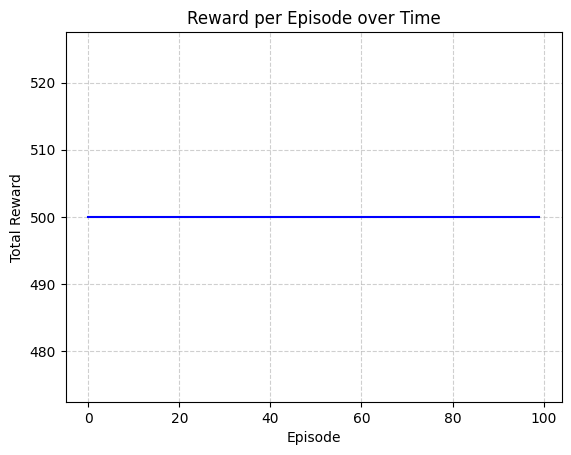

In [ ]:
## Greedy action rollout (10 episodes)

if __name__ == '__main__':

  q_net_cartpole = DQN_agent_cartpole.q_net
  number_episodes = 100
  max_timestep = 500

  env2 = gym.make("CartPole-v1", render_mode="rgb_array")
  agent2 = DQN_Agent_Roll(env2, q_net_cartpole)

  total_reward_list = []
  episodes = list(range(number_episodes))

  for epi in range(number_episodes):
    obs, info = env2.reset()
    terminated, truncated = False, False
    total_reward = 0
    step = 0
    print(epi)

    while not (terminated or truncated):

      state1 = obs
      action = agent2.greedy_step(state1)
      obs, reward, terminated, truncated, info = env2.step(action)
      total_reward += reward
      state2 = obs
      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    total_reward_list.append(total_reward)


  print(f"Avg reward : {np.sum(total_reward_list)/number_episodes}")

  # Plot: Episode vs Reward per Episode
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)




In [ ]:
# saving trained q_net as .h5 file
!pwd
folder_path = '/content/drive/MyDrive/MS/RL/Assignment2/Models/'

filename = folder_path + 'DQN_CartPoleV1_dt.h5'
torch.save(DQN_agent_cartpole.q_net.state_dict(), filename)
print(f"Success! q_net saved to {filename}")

/content
Success! q_net saved to /content/drive/MyDrive/MS/RL/Assignment2/Models/DQN_CartPoleV1_dt.h5


In [ ]:
# --------------------------------------
# MountainCar-v0 (DQN)
# --------------------------------------

In [6]:
import gymnasium as gym
from IPython import display
import matplotlib.pyplot as plt
import math

In [8]:
class net_mountaincar(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(2, 128)
    self.fc2 = nn.Linear(128, 128)
    self.fc3 = nn.Linear(128,3)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x

print(net_mountaincar())

net_mountaincar(
  (fc1): Linear(in_features=2, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=3, bias=True)
)


net_mountaincar(
  (fc1): Linear(in_features=2, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=3, bias=True)
)
net_mountaincar(
  (fc1): Linear(in_features=2, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=3, bias=True)
)
0
-0.010313762
-0.01043076
-0.010944454
-0.010725034
-0.010464008
-0.01142653
-0.010893138
-0.0113959825
-0.01125824
-0.010685896
-0.010667851
-0.0106298765
-0.011195795
-0.011029554
-0.010873604
-0.0097203
-0.010252831
-0.009455246
-0.010856723
-0.009239086
-0.009009841
-0.009761185
-0.010559655
-0.009608891
-0.008634332
-0.010276416
-0.010194157
-0.01014503
-0.00903636
-0.01010163
-0.009189493
-0.010089966
-0.00980547
-0.00951839
-0.009419902
-0.010105495
-0.009688938
-0.010139558
-0.009975157
-0.0098917335
-0.009808124
-0.009991641
-0.009872967
-0.010029965
-0.010183796
-0.010313716
-0.01

/tmp/ipykernel_4039/3512903210.py:52: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  tensor_states1 = torch.tensor(states1, dtype=torch.float32)


Streaming output truncated to the last 5000 lines.
1092
1093
1094
1095
1096
1097
1098
1099
1100
1101
1102
1103
1104
1105
1106
1107
1108
1109
1110
1111
1112
1113
1114
1115
1116
1117
1118
1119
1120
1121
1122
1123
1124
1125
1126
1127
1128
1129
1130
1131
1132
1133
1134
1135
1136
1137
1138
1139
1140
1141
1142
1143
1144
1145
1146
1147
1148
1149
1150
1151
1152
1153
1154
1155
1156
1157
1158
1159
1160
1161
1162
1163
1164
1165
1166
1167
1168
1169
1170
1171
1172
1173
1174
1175
1176
1177
1178
1179
1180
1181
1182
1183
1184
1185
1186
1187
1188
1189
1190
1191
1192
1193
1194
1195
1196
1197
1198
1199
1200
1201
1202
1203
1204
1205
1206
1207
1208
1209
1210
1211
1212
1213
1214
1215
1216
1217
1218
1219
1220
1221
1222
1223
1224
1225
1226
1227
1228
1229
1230
1231
1232
1233
1234
1235
1236
1237
1238
1239
1240
1241
1242
1243
1244
1245
1246
1247
1248
1249
1250
1251
1252
1253
1254
1255
1256
1257
1258
1259
1260
1261
1262
1263
1264
1265
1266
1267
1268
1269
1270
1271
1272
1273
1274
1275
1276
1277
1278
1279
1280
1281

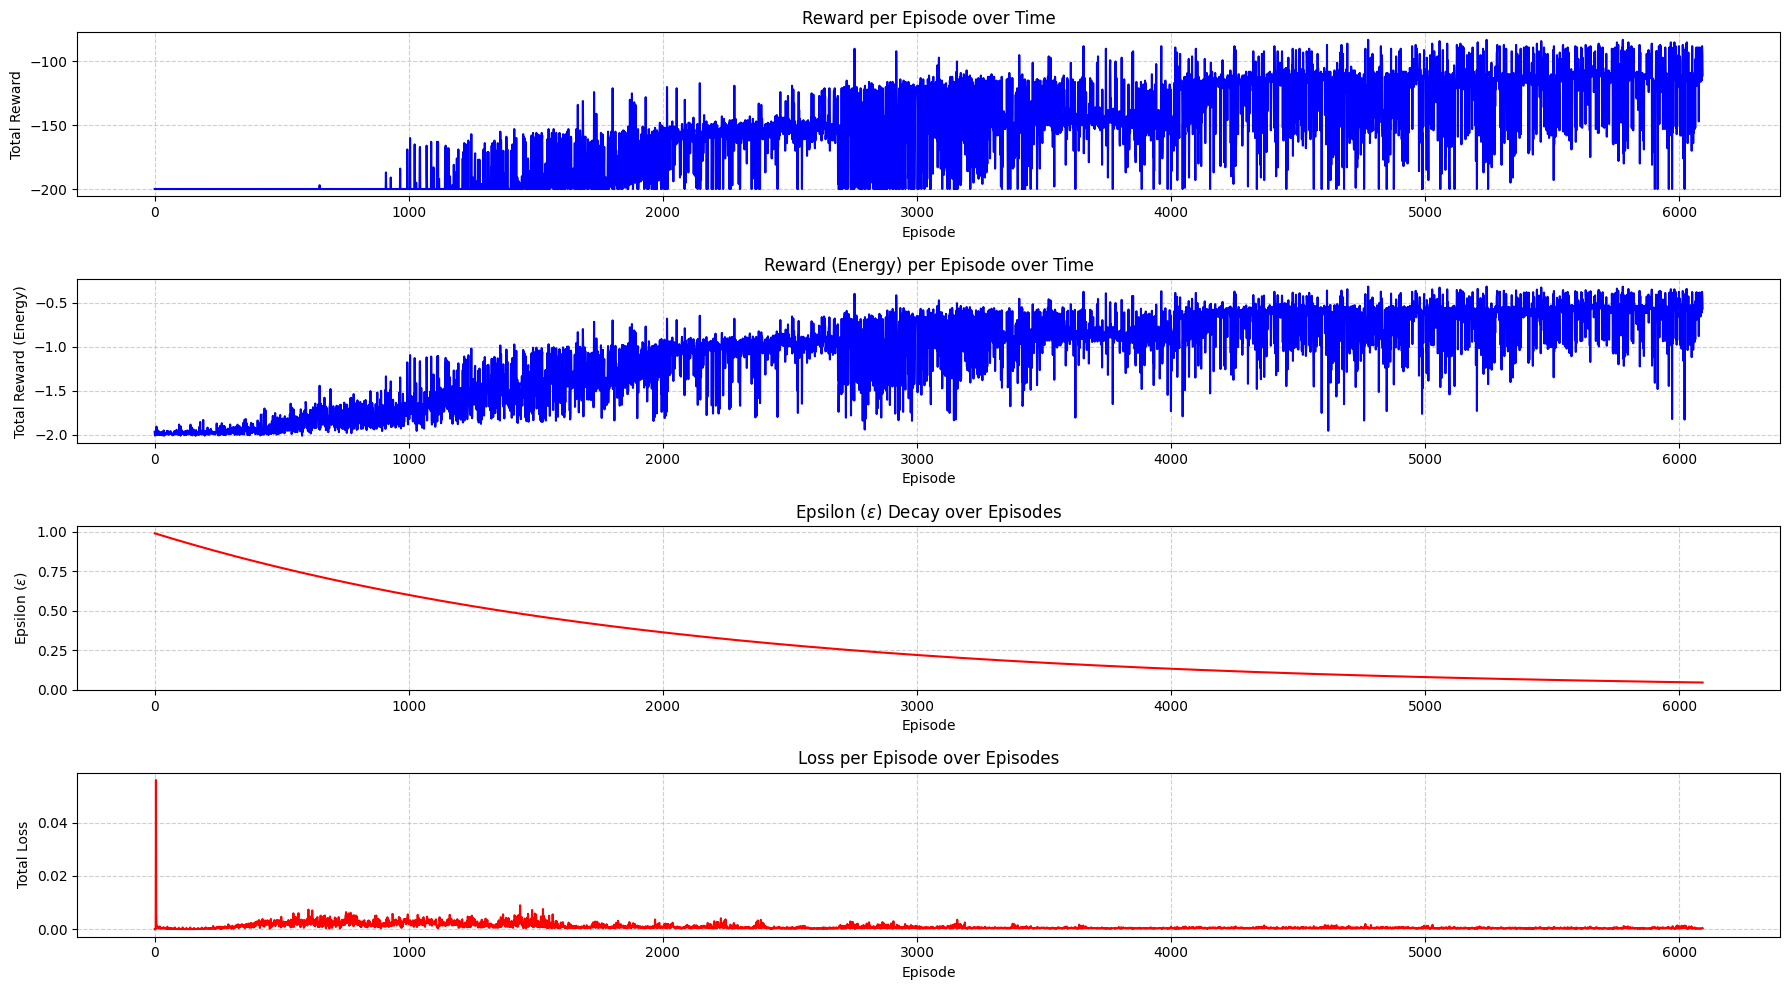

In [9]:
### Mountaincar DQN-learning ###

if __name__ == '__main__':

  alpha = 0.2
  epsilon = 0.99
  epsilon_decay_mag = 0.9995
  gamma = 0.99
  q_net = net_mountaincar()
  target_net = net_mountaincar()
  print(q_net)
  print(target_net)
  number_episodes = 10000
  max_timesteps = 200
  buffer_size = 5000
  training_start_size = 1000
  minibatch_size = 64
  learning_rate = 0.0005
  grad_update_freq = 10
  target_sync_freq = 3000


  # env = GridEnvironmentS2('dt', max_timesteps)
  env = gym.make("MountainCar-v0", render_mode="rgb_array") ## Goal velocity???
  DQN_agent_mountaincar = DQN(env,epsilon,epsilon_decay_mag,alpha,gamma,q_net,target_net,buffer_size,training_start_size, minibatch_size, learning_rate)

  reward_10 = []
  total_reward_list = []
  total_loss_list = []
  total_reward_energy_list = []
  epsilon_list = []
  # episodes = list(range(number_episodes))

  # list_reward_lt_20 = [] ## testing
  # no_reward_lt_20 = 0

  training_start_pointer = 0
  grad_update_pointer = 1
  target_sync_pointer = 1

  for epi in range(number_episodes):
    obs, info = env.reset()
    terminated, truncated = False, False
    total_reward = 0
    total_loss = torch.tensor(0.0)
    total_reward_energy = 0
    step = 0
    print(epi)
    # print(DQN_agent_cartpole.epsilon)
    done = terminated or truncated

    while not done:

      if training_start_pointer < training_start_size:
        state1 = obs
        state = np.reshape(obs, (1, 2))

        action = DQN_agent_mountaincar.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        next_state = np.reshape(obs, (1, 2))
        reward_energy = 100*((math.sin(3*next_state[0,0]) * 0.0025 + 0.5 * next_state[0,1] * next_state[0,1]) - (math.sin(3*state[0,0]) * 0.0025 + 0.5 * state[0,1] * state[0,1])) - 0.01
        print(reward_energy)

        total_reward += reward
        total_reward_energy += reward_energy
        done = terminated or truncated
        state2 = obs
        DQN_agent_mountaincar.buffer_save((state1,action,reward_energy,state2,float(done)))
        training_start_pointer += 1


      elif training_start_pointer >= training_start_size:
        if grad_update_pointer%grad_update_freq == 0:
          loss = DQN_agent_mountaincar.grad_update()
          total_loss += loss
        grad_update_pointer += 1

        if target_sync_pointer%target_sync_freq == 0:
          DQN_agent_mountaincar.target_net_sync()
        target_sync_pointer += 1

        state1 = obs
        state = np.reshape(obs, (1, 2))

        action = DQN_agent_mountaincar.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        next_state = np.reshape(obs, (1, 2))
        reward_energy = 100*((math.sin(3*next_state[0,0]) * 0.0025 + 0.5 * next_state[0,1] * next_state[0,1]) - (math.sin(3*state[0,0]) * 0.0025 + 0.5 * state[0,1] * state[0,1])) - 0.01

        total_reward += reward
        total_reward_energy += reward_energy
        done = terminated or truncated
        state2 = obs
        DQN_agent_mountaincar.buffer_save((state1,action,reward_energy,state2,float(done)))

      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    epsilon_list.append(DQN_agent_mountaincar.epsilon)
    total_reward_list.append(total_reward)
    total_loss_list.append(total_loss.item())
    total_reward_energy_list.append(total_reward_energy)
    DQN_agent_mountaincar.epsilon_decay()

    if len(reward_10) < 15:
      reward_10.append(total_reward)
    elif len(reward_10) == 15:
      reward_10.pop(0)
      reward_10.append(total_reward)

    average_r = sum(reward_10) / len(reward_10)
    if average_r > -100:
      break

    # print(total_reward)
  episodes = list(range(len(total_reward_list)))


  plt.figure(figsize=(18,10))

  # Plot 1: Episode vs Reward per Episode
  plt.subplot(4, 1, 1)
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 2: Episode vs Energy_Reward per Episode
  plt.subplot(4, 1, 2)
  plt.plot(episodes, total_reward_energy_list, color='blue', label='Reward (Energy)')
  plt.title('Reward (Energy) per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward (Energy)')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 3: Episode vs Epsilon per Episode
  plt.subplot(4, 1, 3)
  plt.plot(episodes, epsilon_list, color='red', label=r'$\epsilon$ (Epsilon)')
  plt.title(r'Epsilon ($\epsilon$) Decay over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Epsilon ($\epsilon$)')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 4: Episode vs loss per Episode
  plt.subplot(4, 1, 4)
  plt.plot(episodes, total_loss_list, color='red', label=r'Loss')
  plt.title(r'Loss per Episode over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Total Loss')
  plt.grid(True, linestyle='--', alpha=0.6)

  plt.tight_layout()


In [10]:
mc_dqn_total_reward_list = total_reward_list

0
1
2
3
4
5
6
7
8
9
Avg reward : -107.8


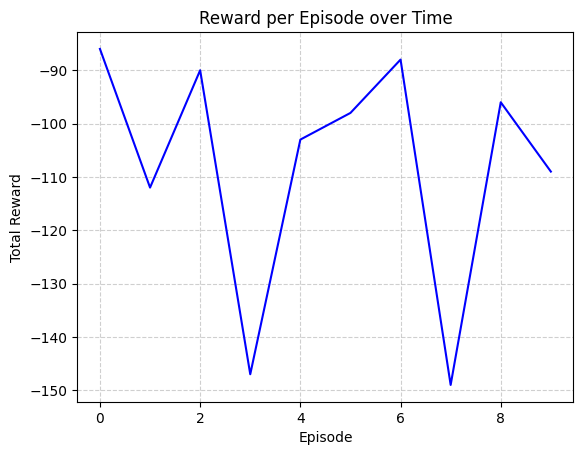

In [11]:
## Greedy action rollout (10 episodes)

if __name__ == '__main__':

  q_net_mountaincar = DQN_agent_mountaincar.q_net
  number_episodes = 10
  max_timestep = 500


  env2 = gym.make("MountainCar-v0", render_mode="rgb_array")
  agent2 = DQN_Agent_Roll(env2, q_net_mountaincar)

  total_reward_list = []
  episodes = list(range(number_episodes))

  for epi in range(number_episodes):
    obs, info = env2.reset()
    terminated, truncated = False, False
    total_reward = 0
    step = 0
    print(epi)

    while not (terminated or truncated):

      state1 = obs
      action = agent2.greedy_step(state1)
      obs, reward, terminated, truncated, info = env2.step(action)
      total_reward += reward
      state2 = obs
      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    total_reward_list.append(total_reward)


  print(f"Avg reward : {np.sum(total_reward_list)/number_episodes}")

  # Plot: Episode vs Reward per Episode
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)




In [12]:
# saving trained q_net as .h5 file
!pwd
folder_path = '/content/drive/MyDrive/MS/RL/Assignment2/Part2/Models/'

filename = folder_path + 'DQN_MountainCarV0_dt.h5'
torch.save(DQN_agent_mountaincar.q_net.state_dict(), filename)
print(f"Success! q_net saved to {filename}")

/content
Success! q_net saved to /content/drive/MyDrive/MS/RL/Assignment2/Part2/Models/DQN_MountainCarV0_dt.h5


In [ ]:
# ----------------------------------------------------------------------------------------------------
################################## DQN improvement - Double DQN #####################################
# ----------------------------------------------------------------------------------------------------

In [ ]:
# -----------------------
# Gridworld - Double DQN
# -----------------------

In [39]:
class net(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(5, 64)
    self.fc2 = nn.Linear(64, 64)
    self.fc3 = nn.Linear(64,6)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x

print(net())

net(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=6, bias=True)
)


net(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=6, bias=True)
)
net(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=6, bias=True)
)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184


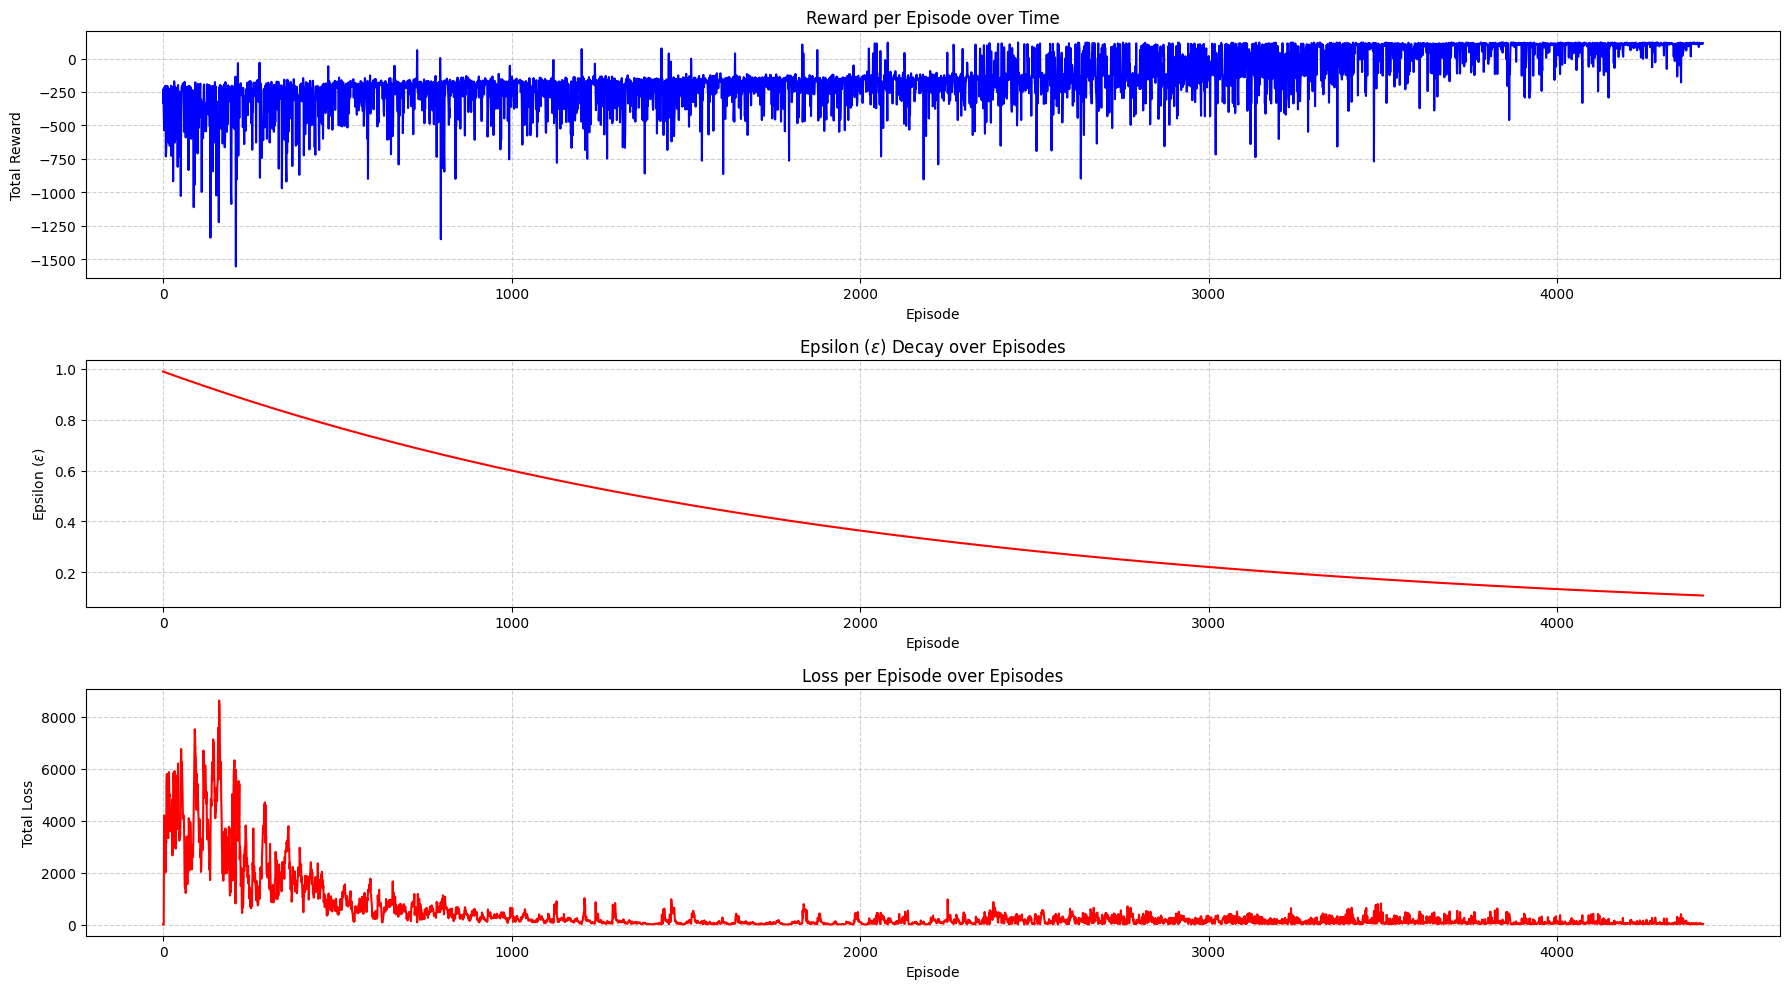

In [40]:
### Gridworld deterministic Env Double DQN-training ###

if __name__ == '__main__':

  alpha = 0.2
  epsilon = 0.99
  epsilon_decay_mag = 0.9995
  gamma = 0.7
  q_net = net()
  target_net = net()
  print(q_net)
  print(target_net)
  number_episodes = 10000
  max_timesteps = 100
  buffer_size = 1000
  training_start_size = 300
  minibatch_size = 64
  learning_rate = 0.001
  grad_update_freq = 4
  target_sync_freq = 200


  env = GridEnvironmentS2('dt', max_timesteps)
  DQN_agent = DQN(env,epsilon,epsilon_decay_mag,alpha,gamma,q_net,target_net,buffer_size,training_start_size, minibatch_size, learning_rate)

  reward_10 = []
  total_reward_list = []
  epsilon_list = []
  total_loss_list = []
  # episodes = list(range(number_episodes))

  # list_reward_lt_20 = [] ## testing
  # no_reward_lt_20 = 0

  training_start_pointer = 0
  grad_update_pointer = 0
  target_sync_pointer = 0

  for epi in range(number_episodes):
    obs, info = env.reset_random_spawn()
    terminated, truncated = False, False
    total_reward = 0
    total_loss = torch.tensor(0.0) # Initializing as a PyTorch tensor
    step = 0
    print(epi)
    # print(env.warehouse_pos)
    # print(DQN_agent.epsilon)
    done = terminated or truncated

    while not done:

      if training_start_pointer < training_start_size:
        state1 = obs
        action = DQN_agent.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
        state2 = obs
        DQN_agent.buffer_save((state1,action,reward,state2,float(done)))
        training_start_pointer += 1

      elif training_start_pointer >= training_start_size:
        if grad_update_pointer%grad_update_freq == 0:
          loss = DQN_agent.grad_update_double_dqn()
          total_loss += loss
        grad_update_pointer += 1

        if target_sync_pointer%target_sync_freq==0:
          DQN_agent.target_net_sync()
        target_sync_pointer += 1

        state1 = obs
        action = DQN_agent.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
        state2 = obs
        DQN_agent.buffer_save((state1,action,reward,state2,float(done)))

      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    epsilon_list.append(DQN_agent.epsilon)
    total_reward_list.append(total_reward)
    total_loss_list.append(total_loss.item())
    DQN_agent.epsilon_decay()
    # print(total_reward)

    if len(reward_10) < 10:
      reward_10.append(total_reward)
    elif len(reward_10) == 10:
      reward_10.pop(0)
      reward_10.append(total_reward)

    result = all(x > 110 for x in reward_10)
    if result:
      break

  episodes = list(range(len(total_reward_list)))


  plt.figure(figsize=(18,10))

  # Plot 1: Episode vs Reward per Episode
  plt.subplot(3, 1, 1)
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 2: Episode vs Epsilon per Episode
  plt.subplot(3, 1, 2)
  plt.plot(episodes, epsilon_list, color='red', label=r'$\epsilon$ (Epsilon)')
  plt.title(r'Epsilon ($\epsilon$) Decay over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Epsilon ($\epsilon$)')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 3: Episode vs loss per Episode
  plt.subplot(3, 1, 3)
  plt.plot(episodes, total_loss_list, color='red', label=r'Loss')
  plt.title(r'Loss per Episode over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Total Loss')
  plt.grid(True, linestyle='--', alpha=0.6)

  plt.tight_layout()


In [41]:
grid_ddqn_total_reward_list = total_reward_list

In [66]:
## Saving reward list

import json
r_folder_path = '/content/drive/MyDrive/MS/RL/Assignment2/Part3/reward lists/'

with open(r_folder_path+"grid_ddqn_total_reward_list.json", 'w') as f:
    json.dump(grid_ddqn_total_reward_list, f)

with open(r_folder_path+"grid_dqn_total_reward_list.json", 'w') as f:
    json.dump(grid_dqn_total_reward_list, f)

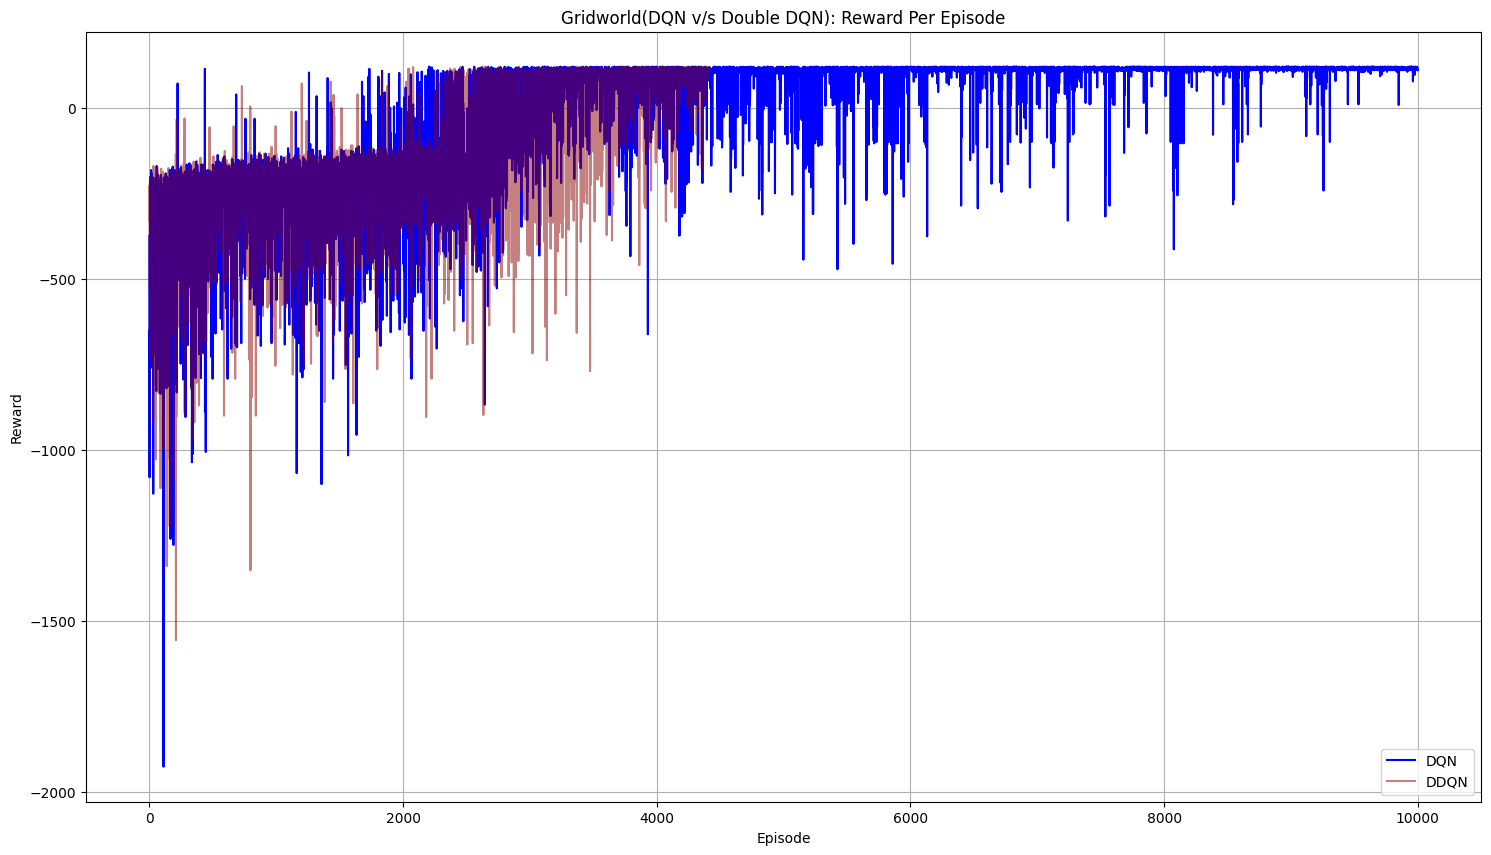

In [64]:
## Gridworld (DQN v/s Double DQN): Reward dynamics graph

graph_len = max(len(grid_ddqn_total_reward_list), len(grid_dqn_total_reward_list))
episodes = list(range(graph_len))

plt.figure(figsize=(18,10))

plt.plot(episodes[:len(grid_dqn_total_reward_list)], grid_dqn_total_reward_list, label='DQN', color='blue' )
plt.plot(episodes[:len(grid_ddqn_total_reward_list)], grid_ddqn_total_reward_list, label='DDQN', alpha=0.5, color='darkred')

plt.title("Gridworld(DQN v/s Double DQN): Reward Per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)

0
1
2
3
4
5
6
7
8
9
Avg reward : 116.2


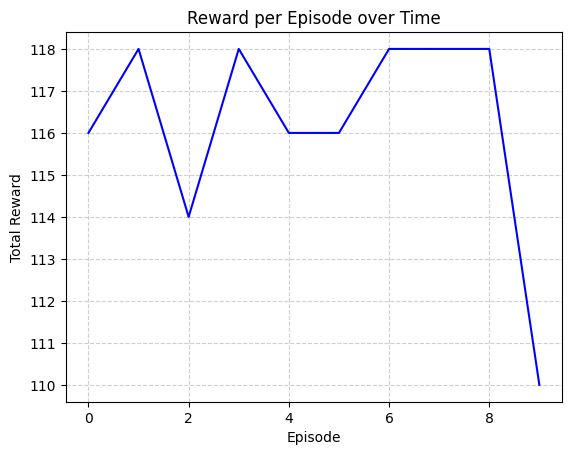

In [12]:
## Greedy action rollout (10 episodes)

if __name__ == '__main__':

  q_net_grid = DQN_agent.q_net
  number_episodes = 10
  max_timestep = 100

  env2 = GridEnvironmentS2('dt', max_timesteps)
  agent2 = DQN_Agent_Roll(env2, q_net_grid)

  total_reward_list = []
  episodes = list(range(number_episodes))

  for epi in range(number_episodes):
    obs, info = env2.reset_random_spawn()
    terminated, truncated = False, False
    total_reward = 0
    step = 0
    print(epi)

    while not (terminated or truncated):

      state1 = obs
      action = agent2.greedy_step(state1)
      obs, reward, terminated, truncated, info = env2.step(action)
      total_reward += reward
      state2 = obs
      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    total_reward_list.append(total_reward)


  print(f"Avg reward : {np.sum(total_reward_list)/number_episodes}")

  # Plot: Episode vs Reward per Episode
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)




In [43]:
# saving trained q_net as .h5 file
!pwd
folder_path = '/content/drive/MyDrive/MS/RL/Assignment2/Part3/Models/'

filename = folder_path + 'Double_DQN_grid_dt.h5'
torch.save(DQN_agent.q_net.state_dict(), filename)
print(f"Success! q_net saved to {filename}")

/content
Success! q_net saved to /content/drive/MyDrive/MS/RL/Assignment2/Part3/Models/Double_DQN_grid_dt.h5


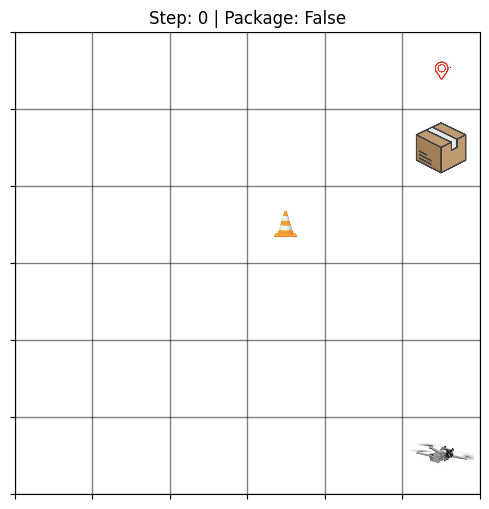

Step: 1 , Agent: [0, 5] , Has Package: False , w_house: [4, 5] , Action: 0 , Reward: -1 , Done: False


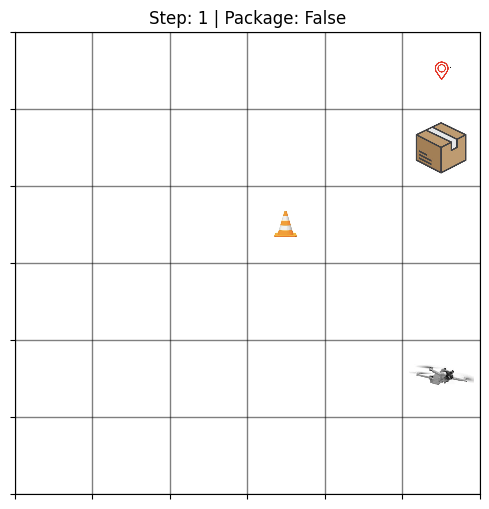

Step: 2 , Agent: [1 5] , Has Package: False , w_house: [4 5] , Action: 0 , Reward: -1 , Done: False


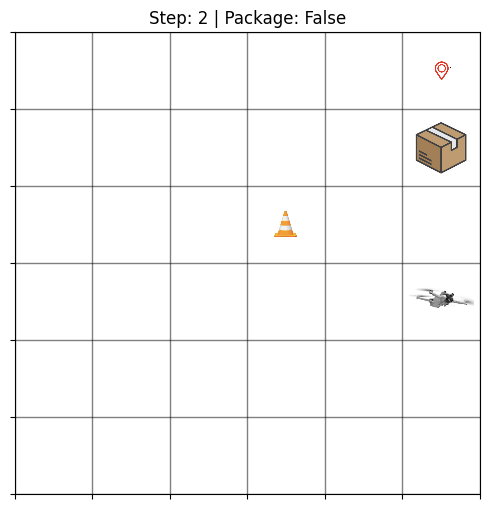

Step: 3 , Agent: [2 5] , Has Package: False , w_house: [4 5] , Action: 0 , Reward: -1 , Done: False


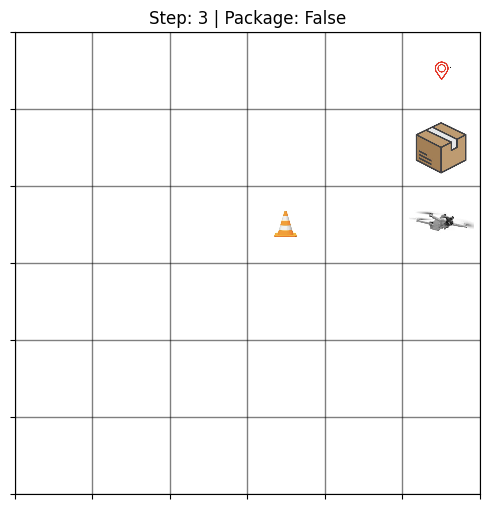

Step: 4 , Agent: [3 5] , Has Package: False , w_house: [4 5] , Action: 0 , Reward: -1 , Done: False


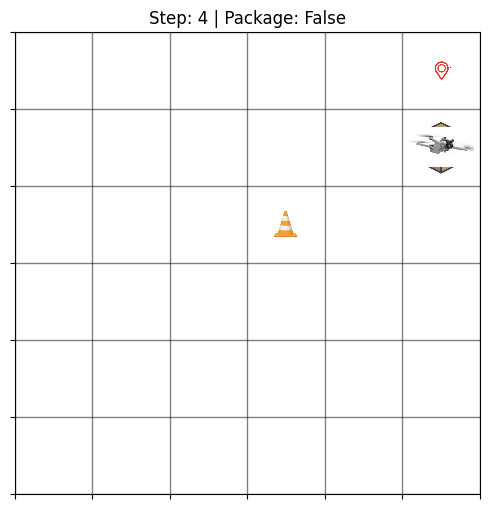

Step: 5 , Agent: [4 5] , Has Package: False , w_house: [4 5] , Action: 4 , Reward: 25 , Done: False


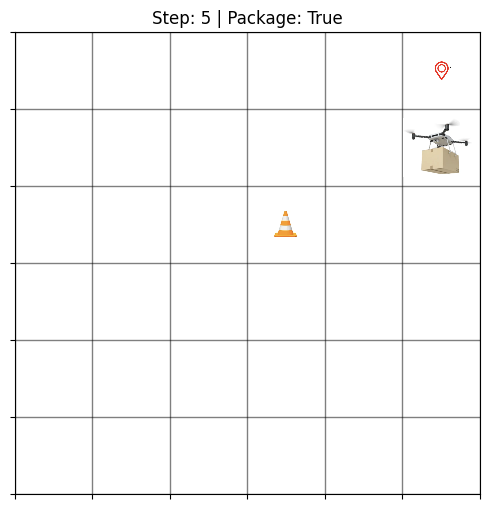

Step: 6 , Agent: [4 5] , Has Package: True , w_house: [4 5] , Action: 0 , Reward: -1 , Done: False


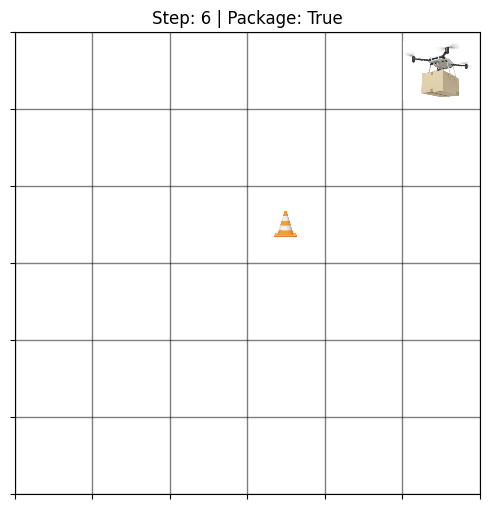

Step: 7 , Agent: [5 5] , Has Package: True , w_house: [5 5] , Action: 5 , Reward: 100 , Done: True


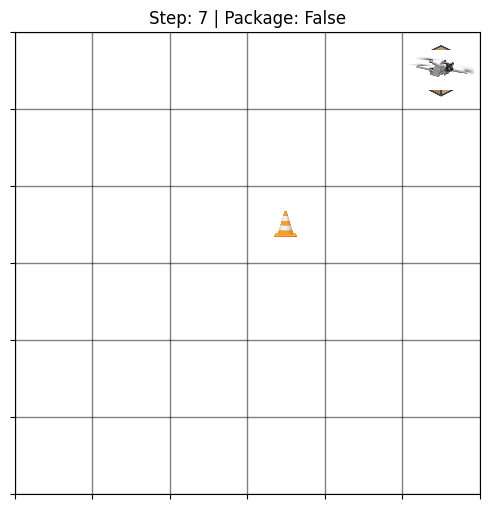

120


In [13]:
## Rendering 1 episode

if __name__ == '__main__':

  q_net_grid = DQN_agent.q_net
  number_episodes = 1
  max_timesteps = 100

  env2 = GridEnvironmentS2('dt', max_timesteps)
  agent2 = DQN_Agent_Roll(env2, q_net_grid)

  for epi in range(number_episodes):
    obs, info = env2.reset_random_spawn()
    terminated, truncated = False, False
    total_reward = 0
    step = 0
    env2.render()

    while not (terminated or truncated):

      state1 = obs
      action = agent2.greedy_step(state1)

      obs, reward, terminated, truncated, info = env2.step(action)

      total_reward += reward
      state2 = obs
      step += 1
      print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      env2.render()
      plt.pause(0.3)

    print(total_reward)




In [ ]:
# --------------------------------------
# CartpoleV1 (Double DQN)
# --------------------------------------

In [14]:
import gymnasium as gym
from IPython import display
import matplotlib.pyplot as plt

In [16]:
class net_cartpole(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(4, 24)
    self.fc2 = nn.Linear(24, 24)
    self.fc3 = nn.Linear(24, 2)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x

print(net_cartpole())

net_cartpole(
  (fc1): Linear(in_features=4, out_features=24, bias=True)
  (fc2): Linear(in_features=24, out_features=24, bias=True)
  (fc3): Linear(in_features=24, out_features=2, bias=True)
)


net_cartpole(
  (fc1): Linear(in_features=4, out_features=24, bias=True)
  (fc2): Linear(in_features=24, out_features=24, bias=True)
  (fc3): Linear(in_features=24, out_features=2, bias=True)
)
net_cartpole(
  (fc1): Linear(in_features=4, out_features=24, bias=True)
  (fc2): Linear(in_features=24, out_features=24, bias=True)
  (fc3): Linear(in_features=24, out_features=2, bias=True)
)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55


/tmp/ipykernel_14887/3512903210.py:90: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  tensor_states1 = torch.tensor(states1, dtype=torch.float32)


56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301
302
303
304
305
306
307
308
309
310
311
312
313
314
315
316


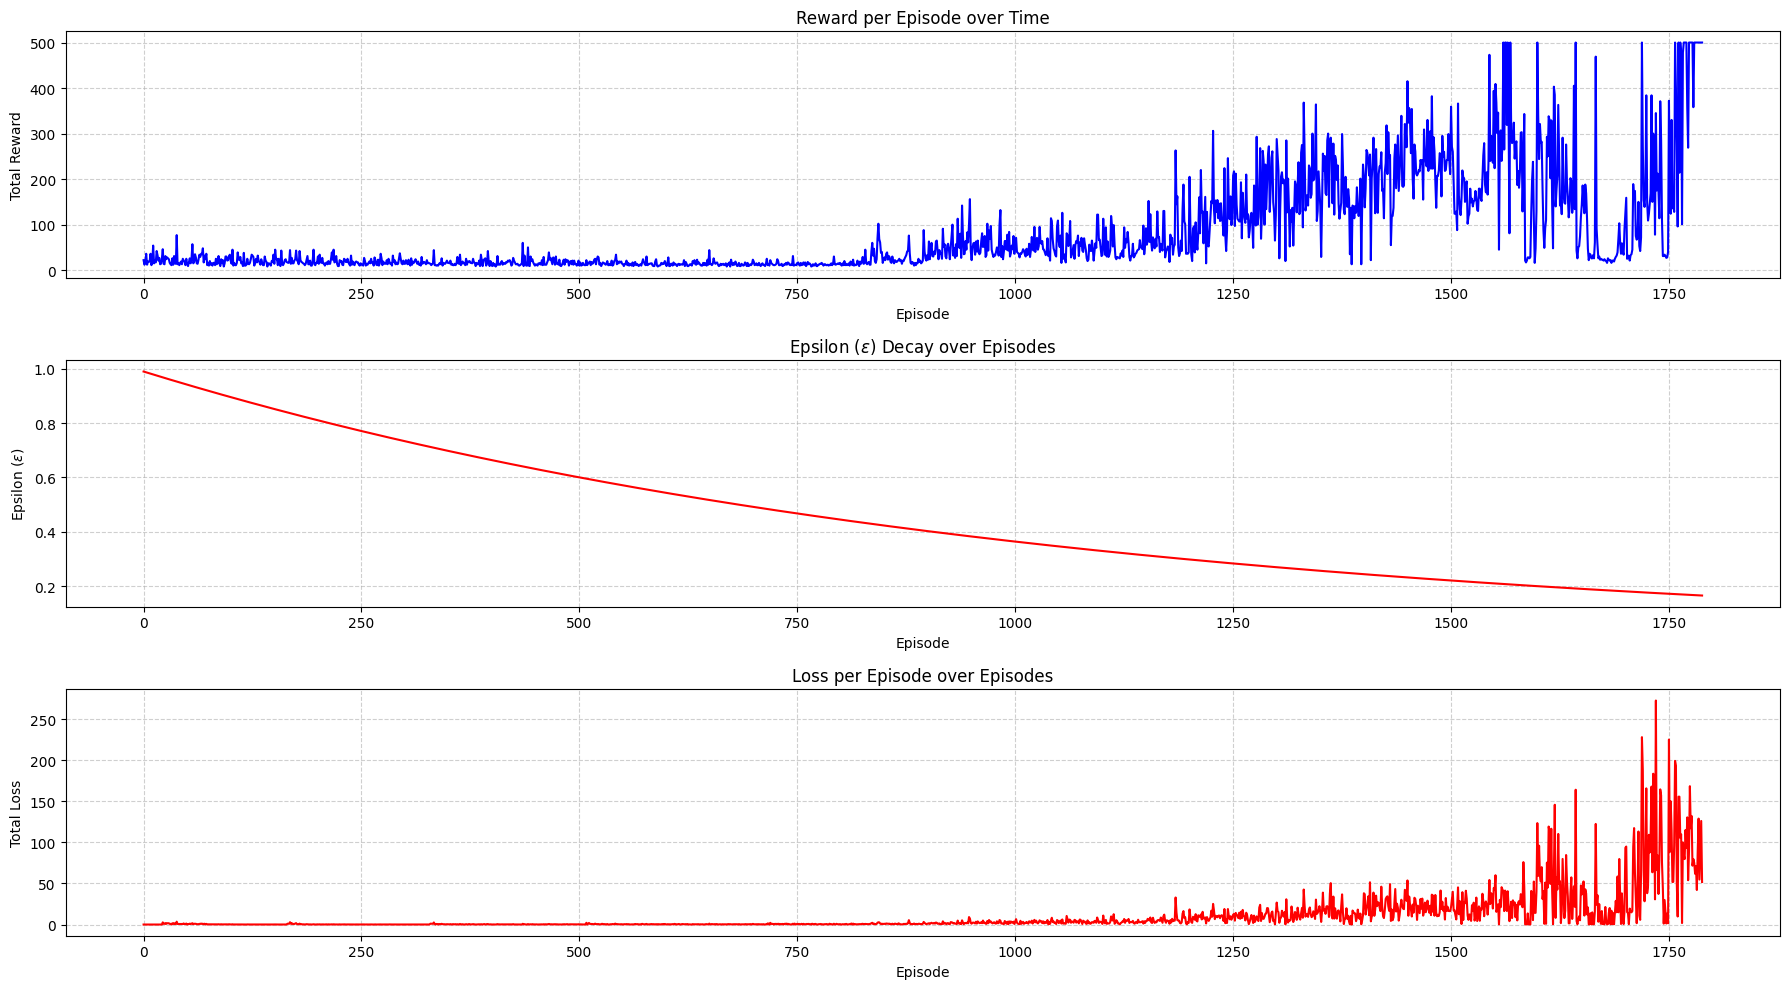

In [17]:
### Cartpole Double DQN-learning ###

if __name__ == '__main__':

  alpha = 0.2
  epsilon = 0.99
  epsilon_decay_mag = 0.999
  gamma = 0.99
  q_net = net_cartpole()
  target_net = net_cartpole()
  print(q_net)
  print(target_net)
  number_episodes = 4000
  max_timesteps = 500
  buffer_size = 10000
  training_start_size = 500
  minibatch_size = 64
  learning_rate = 0.0005
  grad_update_freq = 15
  target_sync_freq = 3000


  # env = GridEnvironmentS2('dt', max_timesteps)
  env = gym.make("CartPole-v1", render_mode="rgb_array")
  DQN_agent_cartpole = DQN(env,epsilon,epsilon_decay_mag,alpha,gamma,q_net,target_net,buffer_size,training_start_size, minibatch_size, learning_rate)

  reward_10 = []
  total_reward_list = []
  total_loss_list = []
  epsilon_list = []

  # list_reward_lt_20 = [] ## testing
  # no_reward_lt_20 = 0

  training_start_pointer = 0
  grad_update_pointer = 1
  target_sync_pointer = 1

  for epi in range(number_episodes):
    obs, info = env.reset()
    terminated, truncated = False, False
    total_reward = 0
    total_loss = torch.tensor(0.0)
    step = 0
    print(epi)
    # print(DQN_agent_cartpole.epsilon)
    done = terminated or truncated

    while not done:

      if training_start_pointer < training_start_size:
        state1 = obs
        action = DQN_agent_cartpole.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
        state2 = obs
        DQN_agent_cartpole.buffer_save((state1,action,reward,state2,float(done)))
        training_start_pointer += 1


      elif training_start_pointer >= training_start_size:
        if grad_update_pointer%grad_update_freq == 0:
          loss = DQN_agent_cartpole.grad_update_double_dqn()
          total_loss += loss
        grad_update_pointer += 1

        if target_sync_pointer%target_sync_freq == 0:
          DQN_agent_cartpole.target_net_sync()
        target_sync_pointer += 1

        state1 = obs
        action = DQN_agent_cartpole.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
        state2 = obs
        DQN_agent_cartpole.buffer_save((state1,action,reward,state2,float(done)))

      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    epsilon_list.append(DQN_agent_cartpole.epsilon)
    total_reward_list.append(total_reward)
    total_loss_list.append(total_loss.item())
    DQN_agent_cartpole.epsilon_decay()
    if len(reward_10) < 10:
      reward_10.append(total_reward)
    elif len(reward_10) == 10:
      reward_10.pop(0)
      reward_10.append(total_reward)

    result = all(x > 470 for x in reward_10)
    if result:
      break
    # print(total_reward)

  episodes = list(range(len(total_reward_list)))

  plt.figure(figsize=(18,10))

  # Plot 1: Episode vs Reward per Episode
  plt.subplot(3, 1, 1)
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 2: Episode vs Epsilon per Episode
  plt.subplot(3, 1, 2)
  plt.plot(episodes, epsilon_list, color='red', label=r'$\epsilon$ (Epsilon)')
  plt.title(r'Epsilon ($\epsilon$) Decay over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Epsilon ($\epsilon$)')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 3: Episode vs loss per Episode
  plt.subplot(3, 1, 3)
  plt.plot(episodes, total_loss_list, color='red', label=r'Loss')
  plt.title(r'Loss per Episode over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Total Loss')
  plt.grid(True, linestyle='--', alpha=0.6)

  plt.tight_layout()


In [18]:
cartpole_ddqn_total_reward_list = total_reward_list

In [71]:
import json
r_folder_path = '/content/drive/MyDrive/MS/RL/Assignment2/Part3/reward lists/'

with open(r_folder_path+"cartpole_ddqn_total_reward_list.json", 'w') as f:
    json.dump(cartpole_ddqn_total_reward_list, f)

with open(r_folder_path+"cartpole_dqn_total_reward_list.json", 'w') as f:
    json.dump(cartpole_dqn_total_reward_list, f)

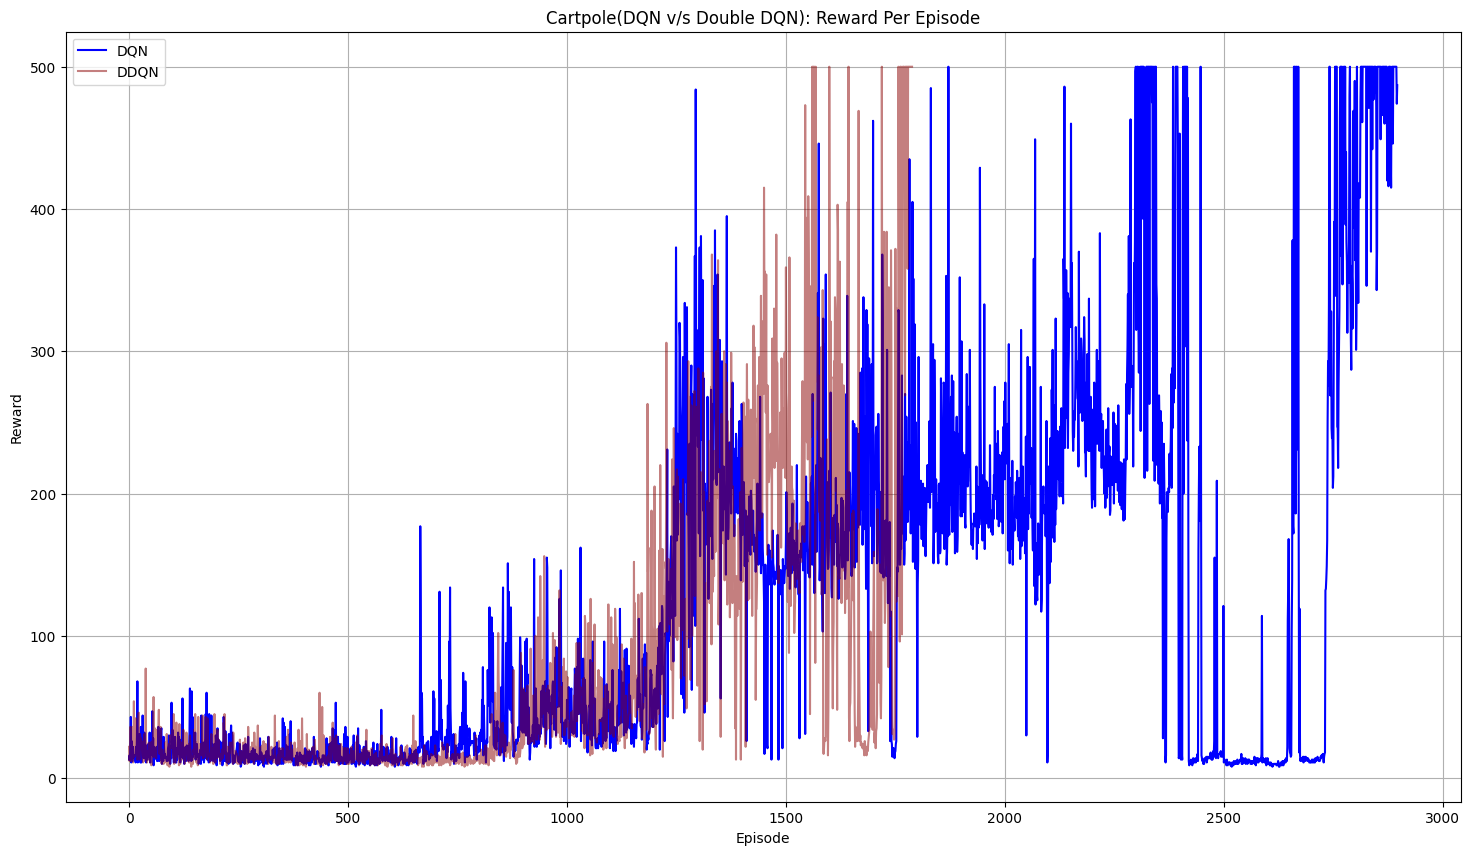

In [73]:
##  Cartpole (DQN v/s Double DQN): Reward dynamics graph

graph_len = max(len(cartpole_ddqn_total_reward_list), len(cartpole_dqn_total_reward_list))
episodes = list(range(graph_len))

plt.figure(figsize=(18,10))

plt.plot(episodes[:len(cartpole_dqn_total_reward_list)], cartpole_dqn_total_reward_list, label='DQN', color='blue' )
plt.plot(episodes[:len(cartpole_ddqn_total_reward_list)], cartpole_ddqn_total_reward_list, label='DDQN', alpha=0.5, color='darkred')

plt.title("Cartpole(DQN v/s Double DQN): Reward Per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
Avg reward : 481.16


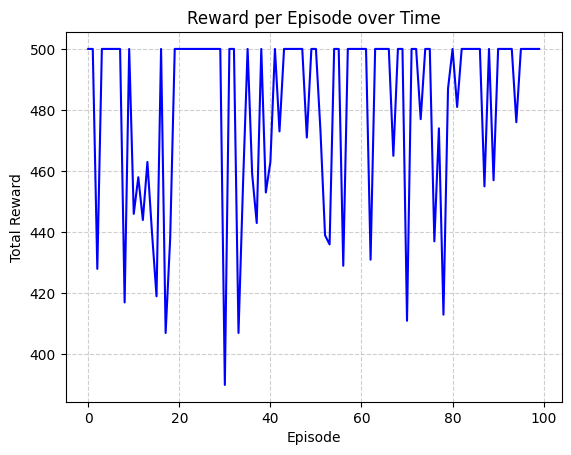

In [19]:
## Greedy action rollout (10 episodes)

if __name__ == '__main__':

  q_net_cartpole = DQN_agent_cartpole.q_net
  number_episodes = 100
  max_timestep = 500

  env2 = gym.make("CartPole-v1", render_mode="rgb_array")
  agent2 = DQN_Agent_Roll(env2, q_net_cartpole)

  total_reward_list = []
  episodes = list(range(number_episodes))

  for epi in range(number_episodes):
    obs, info = env2.reset()
    terminated, truncated = False, False
    total_reward = 0
    step = 0
    print(epi)

    while not (terminated or truncated):

      state1 = obs
      action = agent2.greedy_step(state1)
      obs, reward, terminated, truncated, info = env2.step(action)
      total_reward += reward
      state2 = obs
      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    total_reward_list.append(total_reward)


  print(f"Avg reward : {np.sum(total_reward_list)/number_episodes}")

  # Plot: Episode vs Reward per Episode
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)




In [21]:
# saving trained q_net as .h5 file
!pwd
folder_path = '/content/drive/MyDrive/MS/RL/Assignment2/Part3/Models/'

filename = folder_path + 'Double_DQN_CartPoleV1_dt.h5'
torch.save(DQN_agent_cartpole.q_net.state_dict(), filename)
print(f"Success! q_net saved to {filename}")

/content
Success! q_net saved to /content/drive/MyDrive/MS/RL/Assignment2/Part3/Models/Double_DQN_CartPoleV1_dt.h5


In [ ]:
# --------------------------------------
# MountainCar-v0 (Double DQN)
# --------------------------------------

In [22]:
import gymnasium as gym
from IPython import display
import matplotlib.pyplot as plt
import math

In [109]:
class net_mountaincar(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(2, 128)
    self.fc2 = nn.Linear(128, 128)
    self.fc3 = nn.Linear(128,3)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x

print(net_mountaincar())

net_mountaincar(
  (fc1): Linear(in_features=2, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=3, bias=True)
)


Streaming output truncated to the last 5000 lines.
4212
4213
4214
4215
4216
4217
4218
4219
4220
4221
4222
4223
4224
4225
4226
4227
4228
4229
4230
4231
4232
4233
4234
4235
4236
4237
4238
4239
4240
4241
4242
4243
4244
4245
4246
4247
4248
4249
4250
4251
4252
4253
4254
4255
4256
4257
4258
4259
4260
4261
4262
4263
4264
4265
4266
4267
4268
4269
4270
4271
4272
4273
4274
4275
4276
4277
4278
4279
4280
4281
4282
4283
4284
4285
4286
4287
4288
4289
4290
4291
4292
4293
4294
4295
4296
4297
4298
4299
4300
4301
4302
4303
4304
4305
4306
4307
4308
4309
4310
4311
4312
4313
4314
4315
4316
4317
4318
4319
4320
4321
4322
4323
4324
4325
4326
4327
4328
4329
4330
4331
4332
4333
4334
4335
4336
4337
4338
4339
4340
4341
4342
4343
4344
4345
4346
4347
4348
4349
4350
4351
4352
4353
4354
4355
4356
4357
4358
4359
4360
4361
4362
4363
4364
4365
4366
4367
4368
4369
4370
4371
4372
4373
4374
4375
4376
4377
4378
4379
4380
4381
4382
4383
4384
4385
4386
4387
4388
4389
4390
4391
4392
4393
4394
4395
4396
4397
4398
4399
4400
4401

NameError: name 'b' is not defined

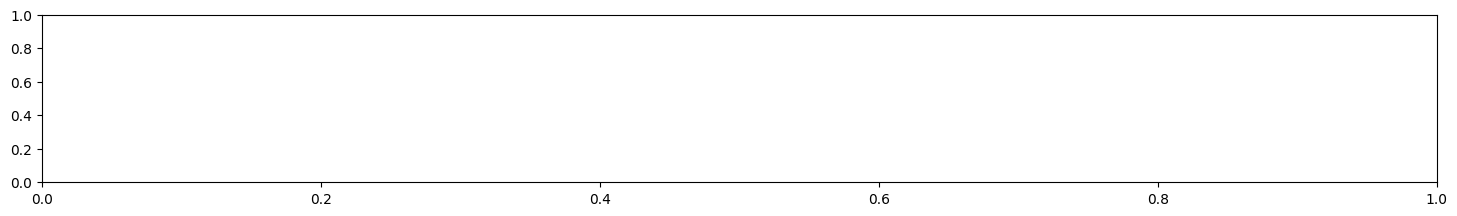

In [110]:
## MountainCar Double DQN-learning

if __name__ == '__main__':

  alpha = 0.2
  epsilon = 0.99
  epsilon_decay_mag = 0.9995
  gamma = 0.99
  q_net = net_mountaincar()
  target_net = net_mountaincar()
  print(q_net)
  print(target_net)
  number_episodes = 10000
  max_timesteps = 200
  buffer_size = 5000
  training_start_size = 1000
  minibatch_size = 64
  learning_rate = 0.0005
  grad_update_freq = 10
  target_sync_freq = 3000


  # env = GridEnvironmentS2('dt', max_timesteps)
  env = gym.make("MountainCar-v0", render_mode="rgb_array") ## Goal velocity???
  DQN_agent_mountaincar = DQN(env,epsilon,epsilon_decay_mag,alpha,gamma,q_net,target_net,buffer_size,training_start_size, minibatch_size, learning_rate)

  reward_10 = []
  total_reward_list = []
  total_loss_list = []
  total_reward_energy_list = []
  epsilon_list = []
  # episodes = list(range(number_episodes))

  # list_reward_lt_20 = [] ## testing
  # no_reward_lt_20 = 0

  training_start_pointer = 0
  grad_update_pointer = 1
  target_sync_pointer = 1

  for epi in range(number_episodes):
    obs, info = env.reset()
    terminated, truncated = False, False
    total_reward = 0
    total_loss = torch.tensor(0.0)
    total_reward_energy = 0
    step = 0
    print(epi)
    # print(DQN_agent_cartpole.epsilon)
    done = terminated or truncated

    while not done:

      if training_start_pointer < training_start_size:
        state1 = obs
        state = np.reshape(obs, (1, 2))

        action = DQN_agent_mountaincar.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        next_state = np.reshape(obs, (1, 2))
        reward_energy = 100*((math.sin(3*next_state[0,0]) * 0.0025 + 0.5 * next_state[0,1] * next_state[0,1]) - (math.sin(3*state[0,0]) * 0.0025 + 0.5 * state[0,1] * state[0,1])) - 0.01
        print(reward_energy)

        total_reward += reward
        total_reward_energy += reward_energy
        done = terminated or truncated
        state2 = obs
        DQN_agent_mountaincar.buffer_save((state1,action,reward_energy,state2,float(done)))
        training_start_pointer += 1


      elif training_start_pointer >= training_start_size:
        if grad_update_pointer%grad_update_freq == 0:
          loss = DQN_agent_mountaincar.grad_update_double_dqn()
          total_loss += loss
        grad_update_pointer += 1

        if target_sync_pointer%target_sync_freq == 0:
          DQN_agent_mountaincar.target_net_sync()
        target_sync_pointer += 1

        state1 = obs
        state = np.reshape(obs, (1, 2))

        action = DQN_agent_mountaincar.step(state1) ### "action" can be of tensor or python int, both works fine
        obs, reward, terminated, truncated, info = env.step(action)
        next_state = np.reshape(obs, (1, 2))
        reward_energy = 100*((math.sin(3*next_state[0,0]) * 0.0025 + 0.5 * next_state[0,1] * next_state[0,1]) - (math.sin(3*state[0,0]) * 0.0025 + 0.5 * state[0,1] * state[0,1])) - 0.01

        total_reward += reward
        total_reward_energy += reward_energy
        done = terminated or truncated
        state2 = obs
        DQN_agent_mountaincar.buffer_save((state1,action,reward_energy,state2,float(done)))

      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    epsilon_list.append(DQN_agent_mountaincar.epsilon)
    total_reward_list.append(total_reward)
    total_loss_list.append(total_loss.item())
    total_reward_energy_list.append(total_reward_energy)
    DQN_agent_mountaincar.epsilon_decay()

    if len(reward_10) < 15:
      reward_10.append(total_reward)
    elif len(reward_10) == 15:
      reward_10.pop(0)
      reward_10.append(total_reward)

    average_r = sum(reward_10) / len(reward_10)
    if average_r > -100:
      break

    # print(total_reward)
  episodes = list(range(len(total_reward_list)))


  plt.figure(figsize=(18,10))

  # Plot 1: Episode vs Reward per Episode
  plt.subplot(4, 1, 1)
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 2: Episode vs Energy_Reward per Episode
  plt.subplot(4, 1, 2)
  plt.plot(episodes, total_reward_energy_list, color='blue', label='Reward (Energy)')
  plt.title('Reward (Energy) per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward (Energy)')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 3: Episode vs Epsilon per Episode
  plt.subplot(4, 1, 3)
  plt.plot(episodes, epsilon_list, color='red', label=r'$\epsilon$ (Epsilon)')
  plt.title(r'Epsilon ($\epsilon$) Decay over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Epsilon ($\epsilon$)')
  plt.grid(True, linestyle='--', alpha=0.6)

  # Plot 4: Episode vs loss per Episode
  plt.subplot(4, 1, 4)
  plt.plot(episodes, total_loss_list, color='red', label=r'Loss')
  plt.title(r'Loss per Episode over Episodes')
  plt.xlabel('Episode')
  plt.ylabel(r'Total Loss')
  plt.grid(True, linestyle='--', alpha=0.6)

  plt.tight_layout()


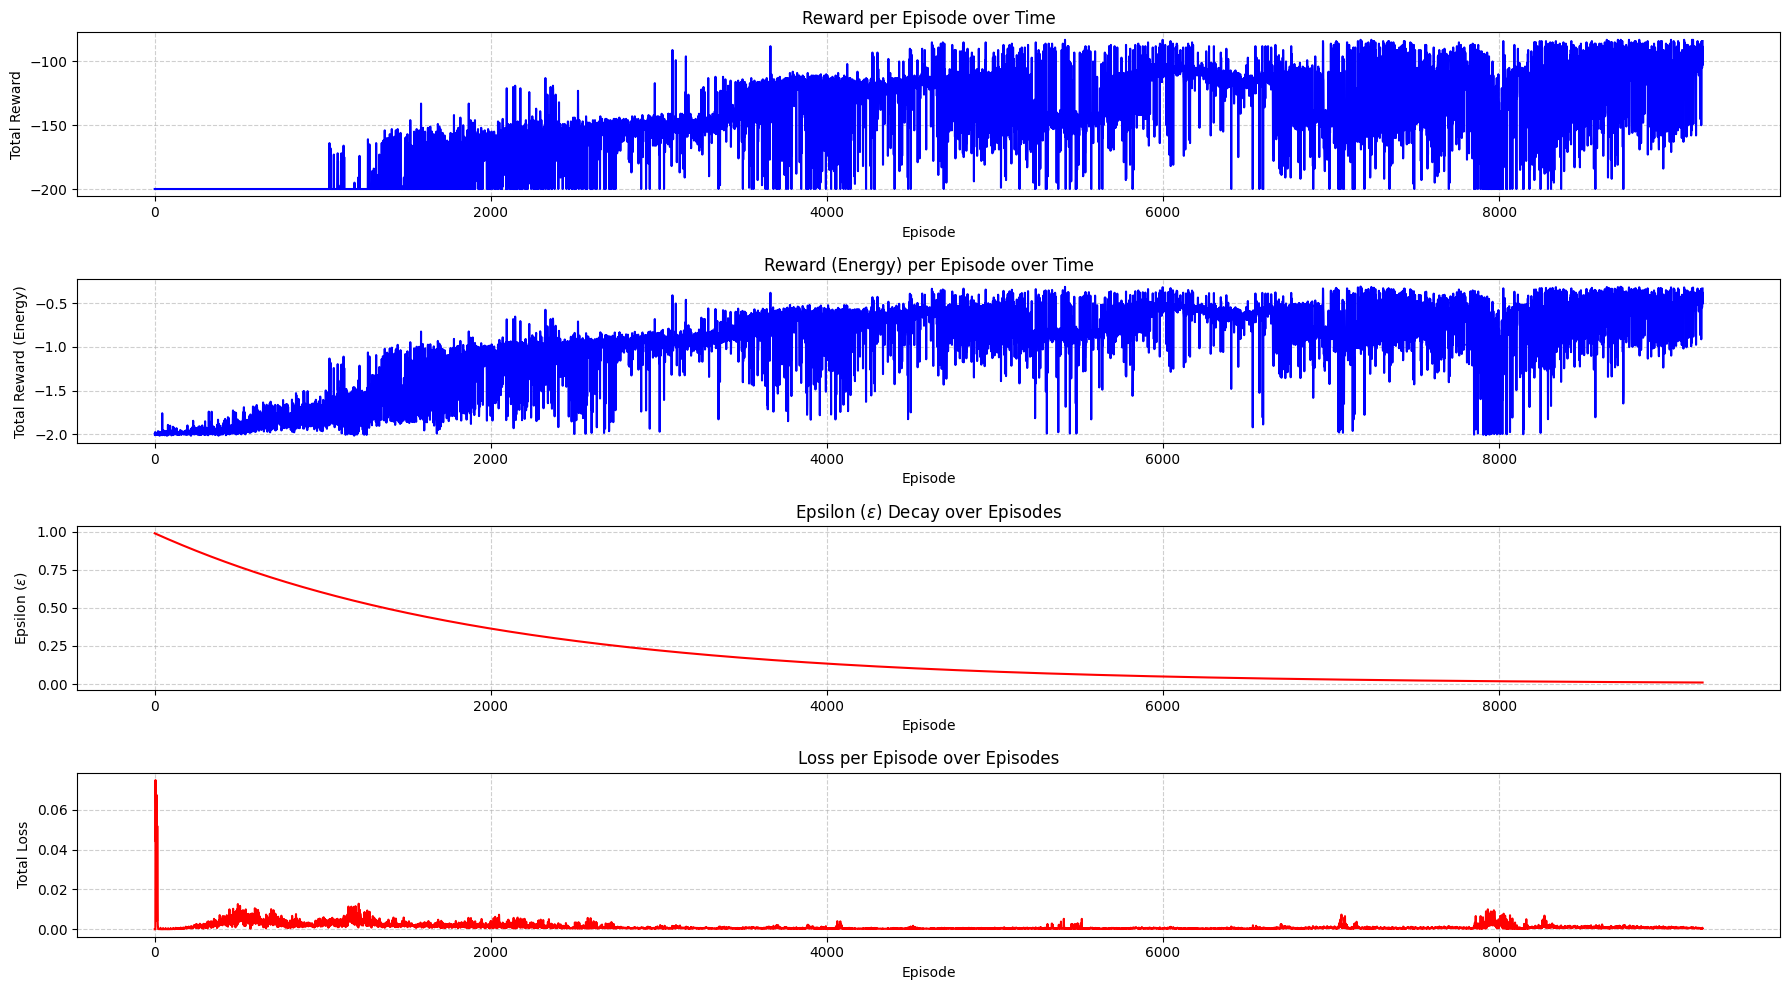

In [111]:
## Plotting graphs

episodes = list(range(len(total_reward_list)))

plt.figure(figsize=(18,10))

# Plot 1: Episode vs Reward per Episode
plt.subplot(4, 1, 1)
plt.plot(episodes, total_reward_list, color='blue', label='Reward')
plt.title('Reward per Episode over Time')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Episode vs Energy_Reward per Episode
plt.subplot(4, 1, 2)
plt.plot(episodes, total_reward_energy_list, color='blue', label='Reward (Energy)')
plt.title('Reward (Energy) per Episode over Time')
plt.xlabel('Episode')
plt.ylabel('Total Reward (Energy)')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Episode vs Epsilon per Episode
plt.subplot(4, 1, 3)
plt.plot(episodes, epsilon_list, color='red', label=r'$\epsilon$ (Epsilon)')
plt.title(r'Epsilon ($\epsilon$) Decay over Episodes')
plt.xlabel('Episode')
plt.ylabel(r'Epsilon ($\epsilon$)')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 4: Episode vs loss per Episode
plt.subplot(4, 1, 4)
plt.plot(episodes, total_loss_list, color='red', label=r'Loss')
plt.title(r'Loss per Episode over Episodes')
plt.xlabel('Episode')
plt.ylabel(r'Total Loss')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

In [112]:
mc_ddqn_total_reward_list = total_reward_list

In [13]:
import json
r_folder_path = '/content/drive/MyDrive/MS/RL/Assignment2/Part3/reward lists/'

with open(r_folder_path+"mc_ddqn_total_reward_list.json", 'w') as f:
    json.dump(mc_ddqn_total_reward_list, f)

with open(r_folder_path+"mc_dqn_total_reward_list.json", 'w') as f:
    json.dump(mc_dqn_total_reward_list, f)

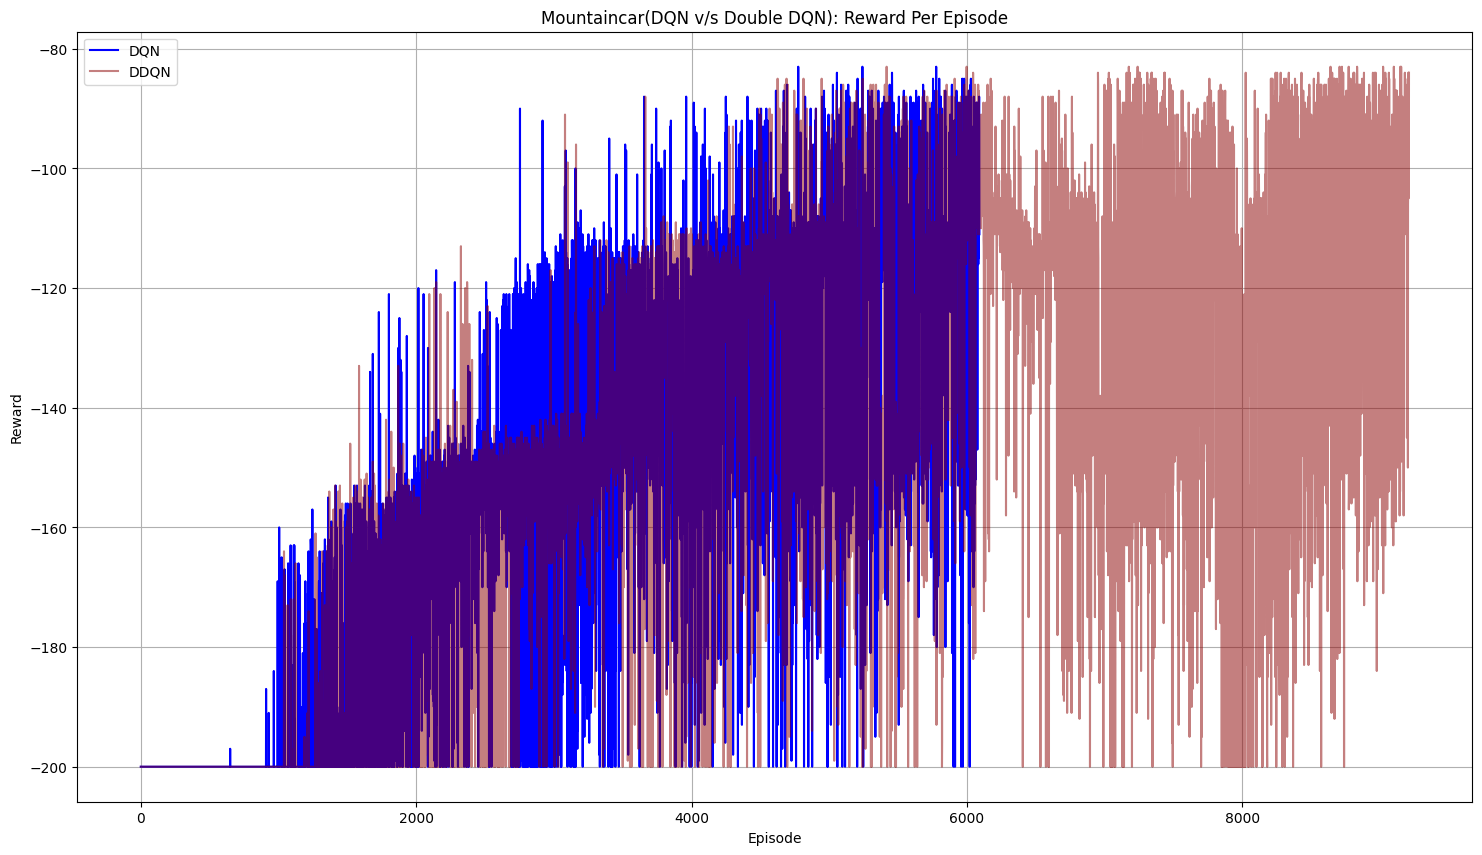

In [16]:
##  Mountaincar(DQN v/s Double DQN): Reward dynamics graph

graph_len = max(len(mc_ddqn_total_reward_list), len(mc_dqn_total_reward_list))
episodes = list(range(graph_len))

plt.figure(figsize=(18,10))

plt.plot(episodes[:len(mc_dqn_total_reward_list)], mc_dqn_total_reward_list, label='DQN', color='blue' )
plt.plot(episodes[:len(mc_ddqn_total_reward_list)], mc_ddqn_total_reward_list, label='DDQN', alpha=0.5, color='darkred')

plt.title("Mountaincar(DQN v/s Double DQN): Reward Per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)

0
1
2
3
4
5
6
7
8
9
Avg reward : -99.4


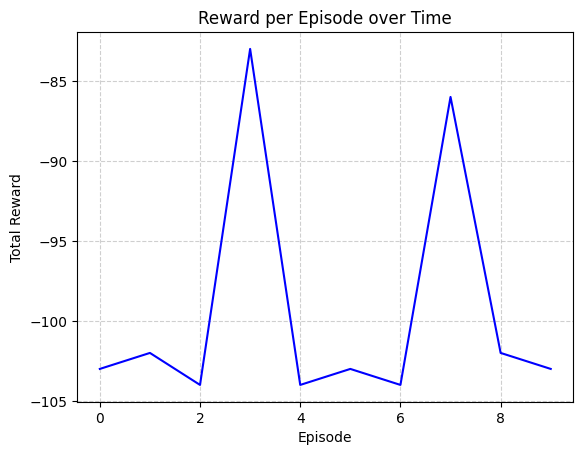

In [114]:
## Greedy action rollout (10 episodes)

if __name__ == '__main__':

  q_net_mountaincar = DQN_agent_mountaincar.q_net
  number_episodes = 10
  max_timestep = 500


  env2 = gym.make("MountainCar-v0", render_mode="rgb_array")
  agent2 = DQN_Agent_Roll(env2, q_net_mountaincar)

  total_reward_list = []
  episodes = list(range(number_episodes))

  for epi in range(number_episodes):
    obs, info = env2.reset()
    terminated, truncated = False, False
    total_reward = 0
    step = 0
    print(epi)

    while not (terminated or truncated):

      state1 = obs
      action = agent2.greedy_step(state1)
      obs, reward, terminated, truncated, info = env2.step(action)
      total_reward += reward
      state2 = obs
      step += 1
      # print('Step:', step ,', Agent:',info['agent_pos'], ', Has Package:', info['has_package'], ', w_house:', info['warehouse_pos'] , ', Action:', action, ', Reward:', reward, ', Done:', terminated)
      # env.render()

    total_reward_list.append(total_reward)


  print(f"Avg reward : {np.sum(total_reward_list)/number_episodes}")

  # Plot: Episode vs Reward per Episode
  plt.plot(episodes, total_reward_list, color='blue', label='Reward')
  plt.title('Reward per Episode over Time')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True, linestyle='--', alpha=0.6)




In [118]:
# saving trained q_net as .h5 file
!pwd
folder_path = '/content/drive/MyDrive/MS/RL/Assignment2/Part3/Models/'

filename = folder_path + 'Double_DQN_MountainCarV0_dt.h5'
torch.save(DQN_agent_mountaincar.q_net.state_dict(), filename)
print(f"Success! q_net saved to {filename}")

/content
Success! q_net saved to /content/drive/MyDrive/MS/RL/Assignment2/Part3/Models/Double_DQN_MountainCarV0_dt.h5


In [ ]:
# ----------------------------------------------------------------------------------------------------